# PARCAST — $E_\mathrm{d}(z,\mathrm{PAR})$, all stations

Processes every in-water file for one field day and compares stations by clock
time and solar zenith angle. All logic lives in `parcast_io.py`.

**Beer–Lambert.** Light decays exponentially with depth:

$$E_\mathrm{d}(z)=E_\mathrm{d}(0^-)\,e^{-K_\mathrm{d} z}\quad\Longrightarrow\quad \ln E_\mathrm{d}(z)=\ln E_\mathrm{d}(0^-)-K_\mathrm{d} z$$

so $K_\mathrm{d}$ (m⁻¹) is the **negative slope** of $\ln E_\mathrm{d}$ regressed on depth, fitted
separately for each cast.

`pip install pvlib`

## Config

In [15]:
import os, sys, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, ".")          # folder holding parcast_io.py
import parcast_io as pio

def version_tuple(v):
    """Numeric version for comparison, so that 6.10 sorts after 6.9."""
    return tuple(int(part) for part in str(v).split("."))

# This notebook needs parcast_io.py v6.7 or later. If the assert fails you are
# running an older copy of the module - replace the file and restart the kernel.
assert version_tuple(getattr(pio, "__version__", "0")) >= (6, 7), (
    f"parcast_io.py is v{getattr(pio,'__version__','<6.7, no version marker')} "
    "- replace it with the v6.7 file and restart the kernel")
print(f"parcast_io v{pio.__version__}")

%matplotlib inline
plt.rcParams.update(pio.PUB_RC)

ED_DIR      = '/Users/loriberberian/Desktop/PARcast/data_processing/raw/E_dzPAR'
FIG_BASE    = '/Users/loriberberian/Desktop/PARcast/data_processing/figures'
LOCAL_DATE  = '20260811'      # keep stations on this LOCAL date; '' = all
FILE_FILTER = ''

# ---- site ------------------------------------------------------------------
# Edit these four lines. The other sites are listed below, copy one across.
#
#   site                        lat        lon      tz                   RTC
#   Galveston, Gulf of Mexico   29.3100    -94.7700  America/Chicago      local
#   Laguna Beach, CA            33.5427   -117.7854  America/Los_Angeles  local
#   North Lake Tahoe, NV        39.1988   -119.9300  America/Los_Angeles  local
#   Santa Barbara Channel       34.2114   -119.9371  America/Los_Angeles  utc
#   Malibu, CA                  34.0375   -118.6775  America/Los_Angeles  utc
#
# Galveston, Laguna and Tahoe are landmark centroids pending the field positions.
# Solar zenith angle moves about 0.1 deg per 0.1 deg of position, so they are
# close enough for the geometry. The time zone is not forgiving in the same way:
# an hour of clock error moves the sun about 15 deg. "America/Texas" is not a
# time zone name and raises at runtime.
SITE_NAME = "Malibu, CA"
SITE_LAT, SITE_LON = 34.0375, -118.6775
SITE_TZ   = "America/Los_Angeles"

# ED_CLOCK is what the profiler RTC was set to on that deployment: "local" for the
# June deployments, "utc" from the v5 firmware onward. The shift is worked out
# from the file's own date rather than typed in, because the offset is not a
# constant: California is -7 in summer and -8 in winter, the Gulf coast is -5 in
# summer. Typing -7 for a Gulf file moves the sun by about 30 deg.
ED_CLOCK = "utc"
_day = (pd.Timestamp(LOCAL_DATE) if LOCAL_DATE
        else pio.first_timestamp(sorted(glob.glob(os.path.join(ED_DIR, "*.CSV")) +
                                        glob.glob(os.path.join(ED_DIR, "*.csv")))[0]))
TZ_SHIFT_H = pio.clock_shift_h(SITE_TZ, _day, ED_CLOCK)

print(f"{SITE_NAME}  {SITE_LAT:.4f}, {SITE_LON:.4f}  {SITE_TZ}")
print(f"  Ed clock {ED_CLOCK}, shift {TZ_SHIFT_H:+.0f} h")

APPLY_IMMERSION = True
TILT_OK_DEG = 5.0
VEL_THR_MS  = 0.02            # m/s of sustained motion to count as profiling
MERGE_GAP_S = 8.0             # pause longer than this starts a new cast
MIN_SPAN_M  = 2.0
MIN_DUR_S   = 10.0
MIN_PTS     = 30

R2_MIN, CV_MAX = 0.98, 10.0   # declare in Methods, before seeing the data

OUTDIR = os.path.join(FIG_BASE, "E_dzPAR_day"); os.makedirs(OUTDIR, exist_ok=True)
def savefig(fig, name, stem=""):
    """Write the PNG, tagged with the day and with the source file where there is one.

    Grid figures cover every station of the day, so they take the date alone. A
    per-station figure takes the station's file stem, which is unique even when two
    files start at the same clock time or the day filter is off.
    """
    tag = stem or globals().get("DAY", LOCAL_DATE or "all")
    path = os.path.join(OUTDIR, f"{name}_{tag}.png")
    fig.savefig(path)
    print("saved", os.path.basename(path))


parcast_io v6.7
Malibu, CA  34.0375, -118.6775  America/Los_Angeles
  Ed clock utc, shift -7 h


## Load and process

Per file: QC → dark runs → regression cutoff → depth zero → cast segmentation →
$K_\mathrm{d}$ fit → solar geometry.

**Regression cutoff** from the capped dark runs. Samples below it stay in the
figures and are left out of the $K_\mathrm{d}$ fit:

$$\mathrm{MIN}\_E_\mathrm{d}=\bar E_\text{dark}+3\sigma_\text{dark}$$

**Depth zero.** The pressure sensor reads *absolute* pressure, so its dry zero
drifts. The median depth during an in-air dark run is that offset; with two or
more runs it is interpolated in time.

**Solar geometry** at each cast midpoint (the angle moves across a descent at
low sun), from the SPA of Reda & Andreas (2004). Snell's law gives the in-water
angle, and the **path factor** is the extra photon path per unit depth:

$$\theta_\mathrm{w}=\arcsin\!\left(\frac{\sin\theta_\mathrm{z}}{n}\right),\ n=1.34
\qquad\text{path factor}=\frac{1}{\cos\theta_\mathrm{w}}$$

Files are grouped by **corrected local date** — casts after 17:00 PDT crossed
midnight UTC, so the logger named them with the next date.

`require_casts=True` drops files with no qualifying down-cast (a dark-only
file, for instance). Such a file has no $K_\mathrm{d}$ and no solar geometry, so it
would otherwise render as an empty panel in every figure. Anything dropped is
listed with the reason.

In [16]:
stations = pio.load_day(ED_DIR, SITE_LAT, SITE_LON, SITE_TZ,
    local_date=LOCAL_DATE, file_filter=FILE_FILTER, tz_shift_h=TZ_SHIFT_H,
    apply_immersion=APPLY_IMMERSION, vel_thr=VEL_THR_MS,
    merge_gap_s=MERGE_GAP_S, min_span_m=MIN_SPAN_M, min_dur_s=MIN_DUR_S,
    min_pts=MIN_PTS, verbose=True, require_casts=True)

print(f"\n{'station':<26} {'start':<6} {'casts':>5} {'SZA':>7} {'1/cosθw':>8} "
      f"{'MIN_ED':>7} {'dark':>5}")
for s in stations:
    print(f"{s['stem']:<26} {s['t0']:%H:%M} {len(s['casts']):5d} {s['sza']:7.2f} "
          f"{s['path_factor']:8.3f} {s['min_ed']:7.2f} {len(s['dark']):5d}")

# One field day per run. LOCAL_DATE filters the files, so a date left over from an
# earlier run silently keeps that day and every figure below is drawn from it, no
# matter which file you meant to look at. Stations from two dates would also share
# one solar noon and one AM/PM split, neither of which holds across days.
dates = sorted({f"{s['t0']:%Y%m%d}" for s in stations})
assert dates, "no stations kept - check LOCAL_DATE against the 'local' column above"
if len(dates) > 1:
    print(f"\n** stations span {len(dates)} local dates: {', '.join(dates)}. "
          "Set LOCAL_DATE to one of them and run once per day.")
DAY = LOCAL_DATE or dates[0]
sun = pio.solar_noon(DAY, SITE_LAT, SITE_LON, SITE_TZ)
print(f"\n{DAY}  sunrise {sun['sunrise']:%H:%M}  solar noon {sun['transit']:%H:%M}  "
      f"sunset {sun['sunset']:%H:%M}")

26 file(s) matching 'E_dzPAR' in /Users/loriberberian/Desktop/PARcast/data_processing/raw/E_dzPAR
keeping local date 20260811

file                         logged           local             casts  status
----------------------------------------------------------------------------------
E_dzPAR_20260524_0001.CSV                                              FAILED IndexError
E_dzPAR_20260524_0002.CSV    2026-05-24 11:49  2026-05-24 04:49       0  skipped (local date 2026-05-24)
E_dzPAR_20260524_0003.CSV    2026-05-24 13:16  2026-05-24 06:16       0  skipped (local date 2026-05-24)
E_dzPAR_20260524_0004.CSV    2026-05-24 13:19  2026-05-24 06:19       0  skipped (local date 2026-05-24)
E_dzPAR_20260524_0005.CSV    2026-05-24 13:24  2026-05-24 06:24       0  skipped (local date 2026-05-24)
E_dzPAR_20260524_112310.csv  2026-05-24 11:23  2026-05-24 04:23       0  skipped (local date 2026-05-24)
E_dzPAR_20260524_114411.csv                                            FAILED IndexError
E_dzPAR_2

## Station summary

$$\mathrm{CV}=100\,\frac{s_{K_\mathrm{d}}}{\bar K_\mathrm{d}}\qquad
\zeta=K_\mathrm{d} z\qquad
\%\mathrm{PAR}(z)=100\,e^{-K_\mathrm{d} z}$$

**%PAR** is reported only at depths actually
sampled (1, 2 and 3 m; the deepest cast of the day reached 4.51 m). 

**Euphotic depth** $z_{1\%}=4.605/K_\mathrm{d}$ is **not** reported because it would have been a ~6 fold extraplotation. If we had sampled deepr, across multiple optical depths we could

Uncertainty is the SD **across replicate casts**, not the regression standard
error — samples within a cast are autocorrelated, so the nominal SE is roughly
an order of magnitude too narrow.

Optical depth $\zeta$ is the quality check: below ~1 the light decays by less
than a factor of $e$ across the profile and the slope is weakly constrained.

**Geometric normalisation** (Gordon 1989) puts every cast on a common
illumination geometry, so water-column change becomes visible:

$$K_\mathrm{d}^{\text{norm}}=K_\mathrm{d}\cos\theta_\mathrm{w}=\frac{K_\mathrm{d}}{\text{path factor}}$$

In [17]:
tbl = pio.station_table(stations, noon=sun["transit"], r2_min=R2_MIN, cv_max=CV_MAX)
show = ["station","sza","path_factor","limb","n","Kd","Kd_sd","cv","r2_min",
        "z_max","optical_depth","pct_at_zmax","Kd_norm","ok"]
display(tbl[[c for c in show if c in tbl]].round(
    {"sza":2,"path_factor":3,"Kd":4,"Kd_sd":4,"cv":1,"r2_min":3,
     "z_max":2,"optical_depth":2,"pct_at_zmax":1,"Kd_norm":4}))

print(f"path factor {tbl.path_factor.min():.3f}–{tbl.path_factor.max():.3f}")
print(f"  geometry alone predicts {100*(tbl.path_factor.max()/tbl.path_factor.min()-1):.1f}%")
print(f"  observed range          {100*(tbl.Kd.max()/tbl.Kd.min()-1):.1f}%")
print(f"  after Kd·cos θw         {100*(tbl.Kd_norm.max()/tbl.Kd_norm.min()-1):.1f}%")
if (tbl.optical_depth < 1).any():
    print(f"** {(tbl.optical_depth<1).sum()} station(s) with ζ < 1 — Kd weakly constrained")
print(f"\n%PAR reference depths {pio.REF_DEPTHS} - deepest cast of the day "
      f"reached {tbl.z_max.min():.2f} m at the shallowest station")
print(f"light remaining at each station's deepest sample: "
      f"{tbl.pct_at_zmax.min():.1f}-{tbl.pct_at_zmax.max():.1f}%")

,station,sza,path_factor,limb,n,Kd,Kd_sd,cv,r2_min,z_max,optical_depth,pct_at_zmax,Kd_norm,ok
0,11:15,26.94,1.063,AM,7,0.2167,0.0389,18.0,0.368,4.80,1.00,37.4,0.2039,False
1,12:13,19.66,1.033,AM,7,0.1816,0.0256,14.1,0.353,4.51,0.79,45.5,0.1758,False
2,13:01,19.27,1.032,PM,9,0.1845,0.0364,19.7,0.125,4.52,0.79,46.0,0.1789,False
3,14:07,27.27,1.064,PM,10,0.2024,0.0190,9.4,0.460,4.66,0.90,40.6,0.1901,False
4,15:54,48.41,1.205,PM,17,0.2598,0.0383,14.7,0.760,6.85,1.38,25.7,0.2151,False
5,17:21,65.30,1.360,PM,11,0.2862,0.0159,5.6,0.833,5.46,1.48,22.8,0.2104,False
6,18:57,83.73,1.491,PM,6,0.3214,0.0057,1.8,0.982,6.29,1.87,15.5,0.2155,True


path factor 1.032–1.491
  geometry alone predicts 44.5%
  observed range          77.0%
  after Kd·cos θw         22.6%
** 4 station(s) with ζ < 1 — Kd weakly constrained

%PAR reference depths (1.0, 2.0, 3.0) - deepest cast of the day reached 4.51 m at the shallowest station
light remaining at each station's deepest sample: 15.5-46.0%


## Fig 1 — casting windows

Cropped to the casts ±1.5 min; most of each record is dark time and transit.
Use `pad_min=None` for the full record.

saved timeline_20260811.png


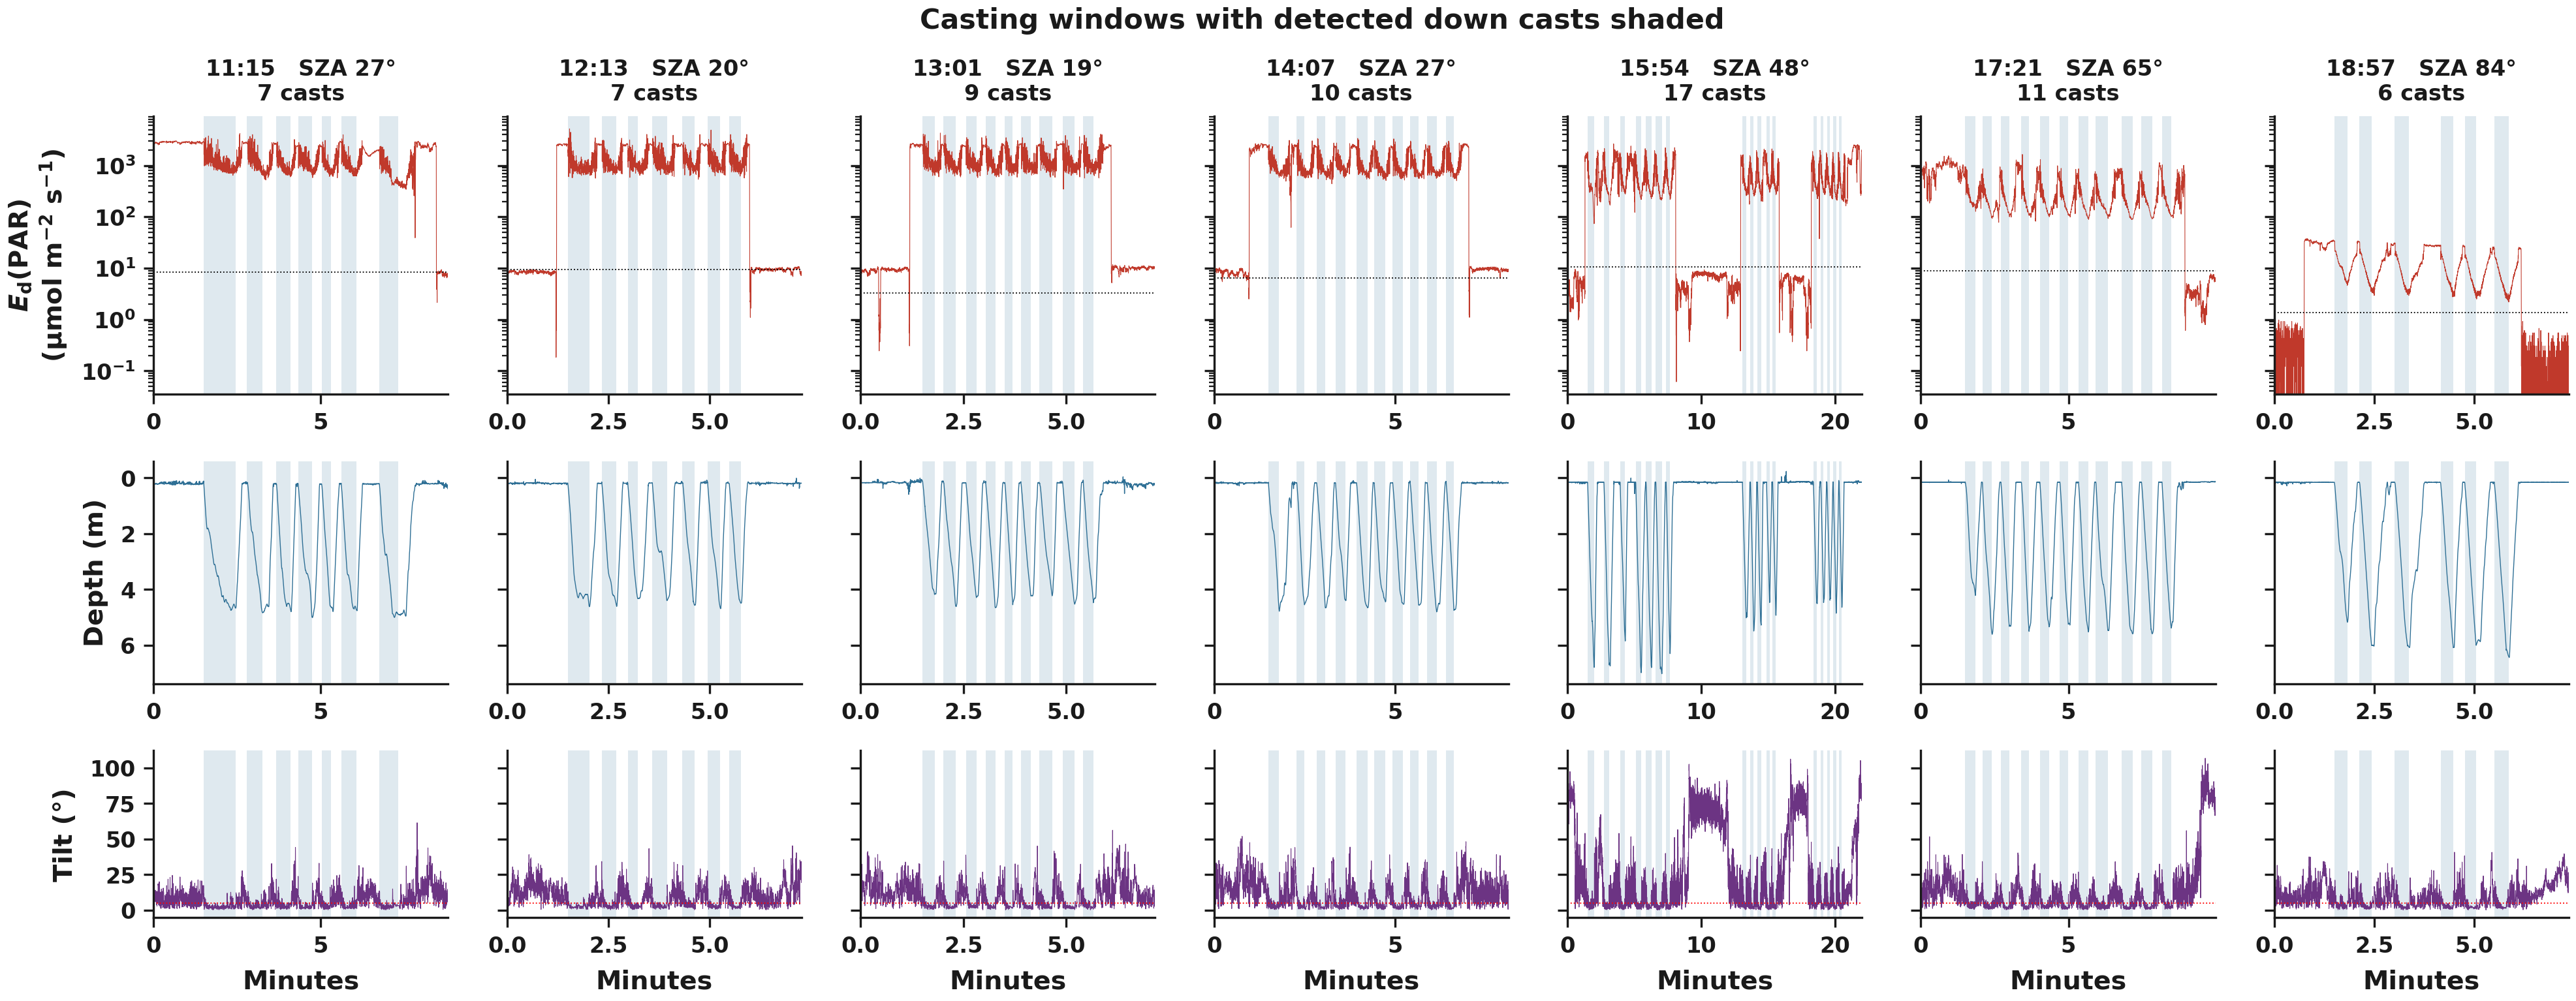

In [18]:
savefig(pio.fig_timeline_grid(stations, TILT_OK_DEG, pad_min=1.5), "timeline"); plt.show()

## Fig 2 — depth profiles

Exponential decay is a straight line on a log x-axis. Curvature at depth means
the signal is nearing the noise floor; horizontal scatter between replicates is
wave-driven variability, not error.

saved profiles_20260811.png


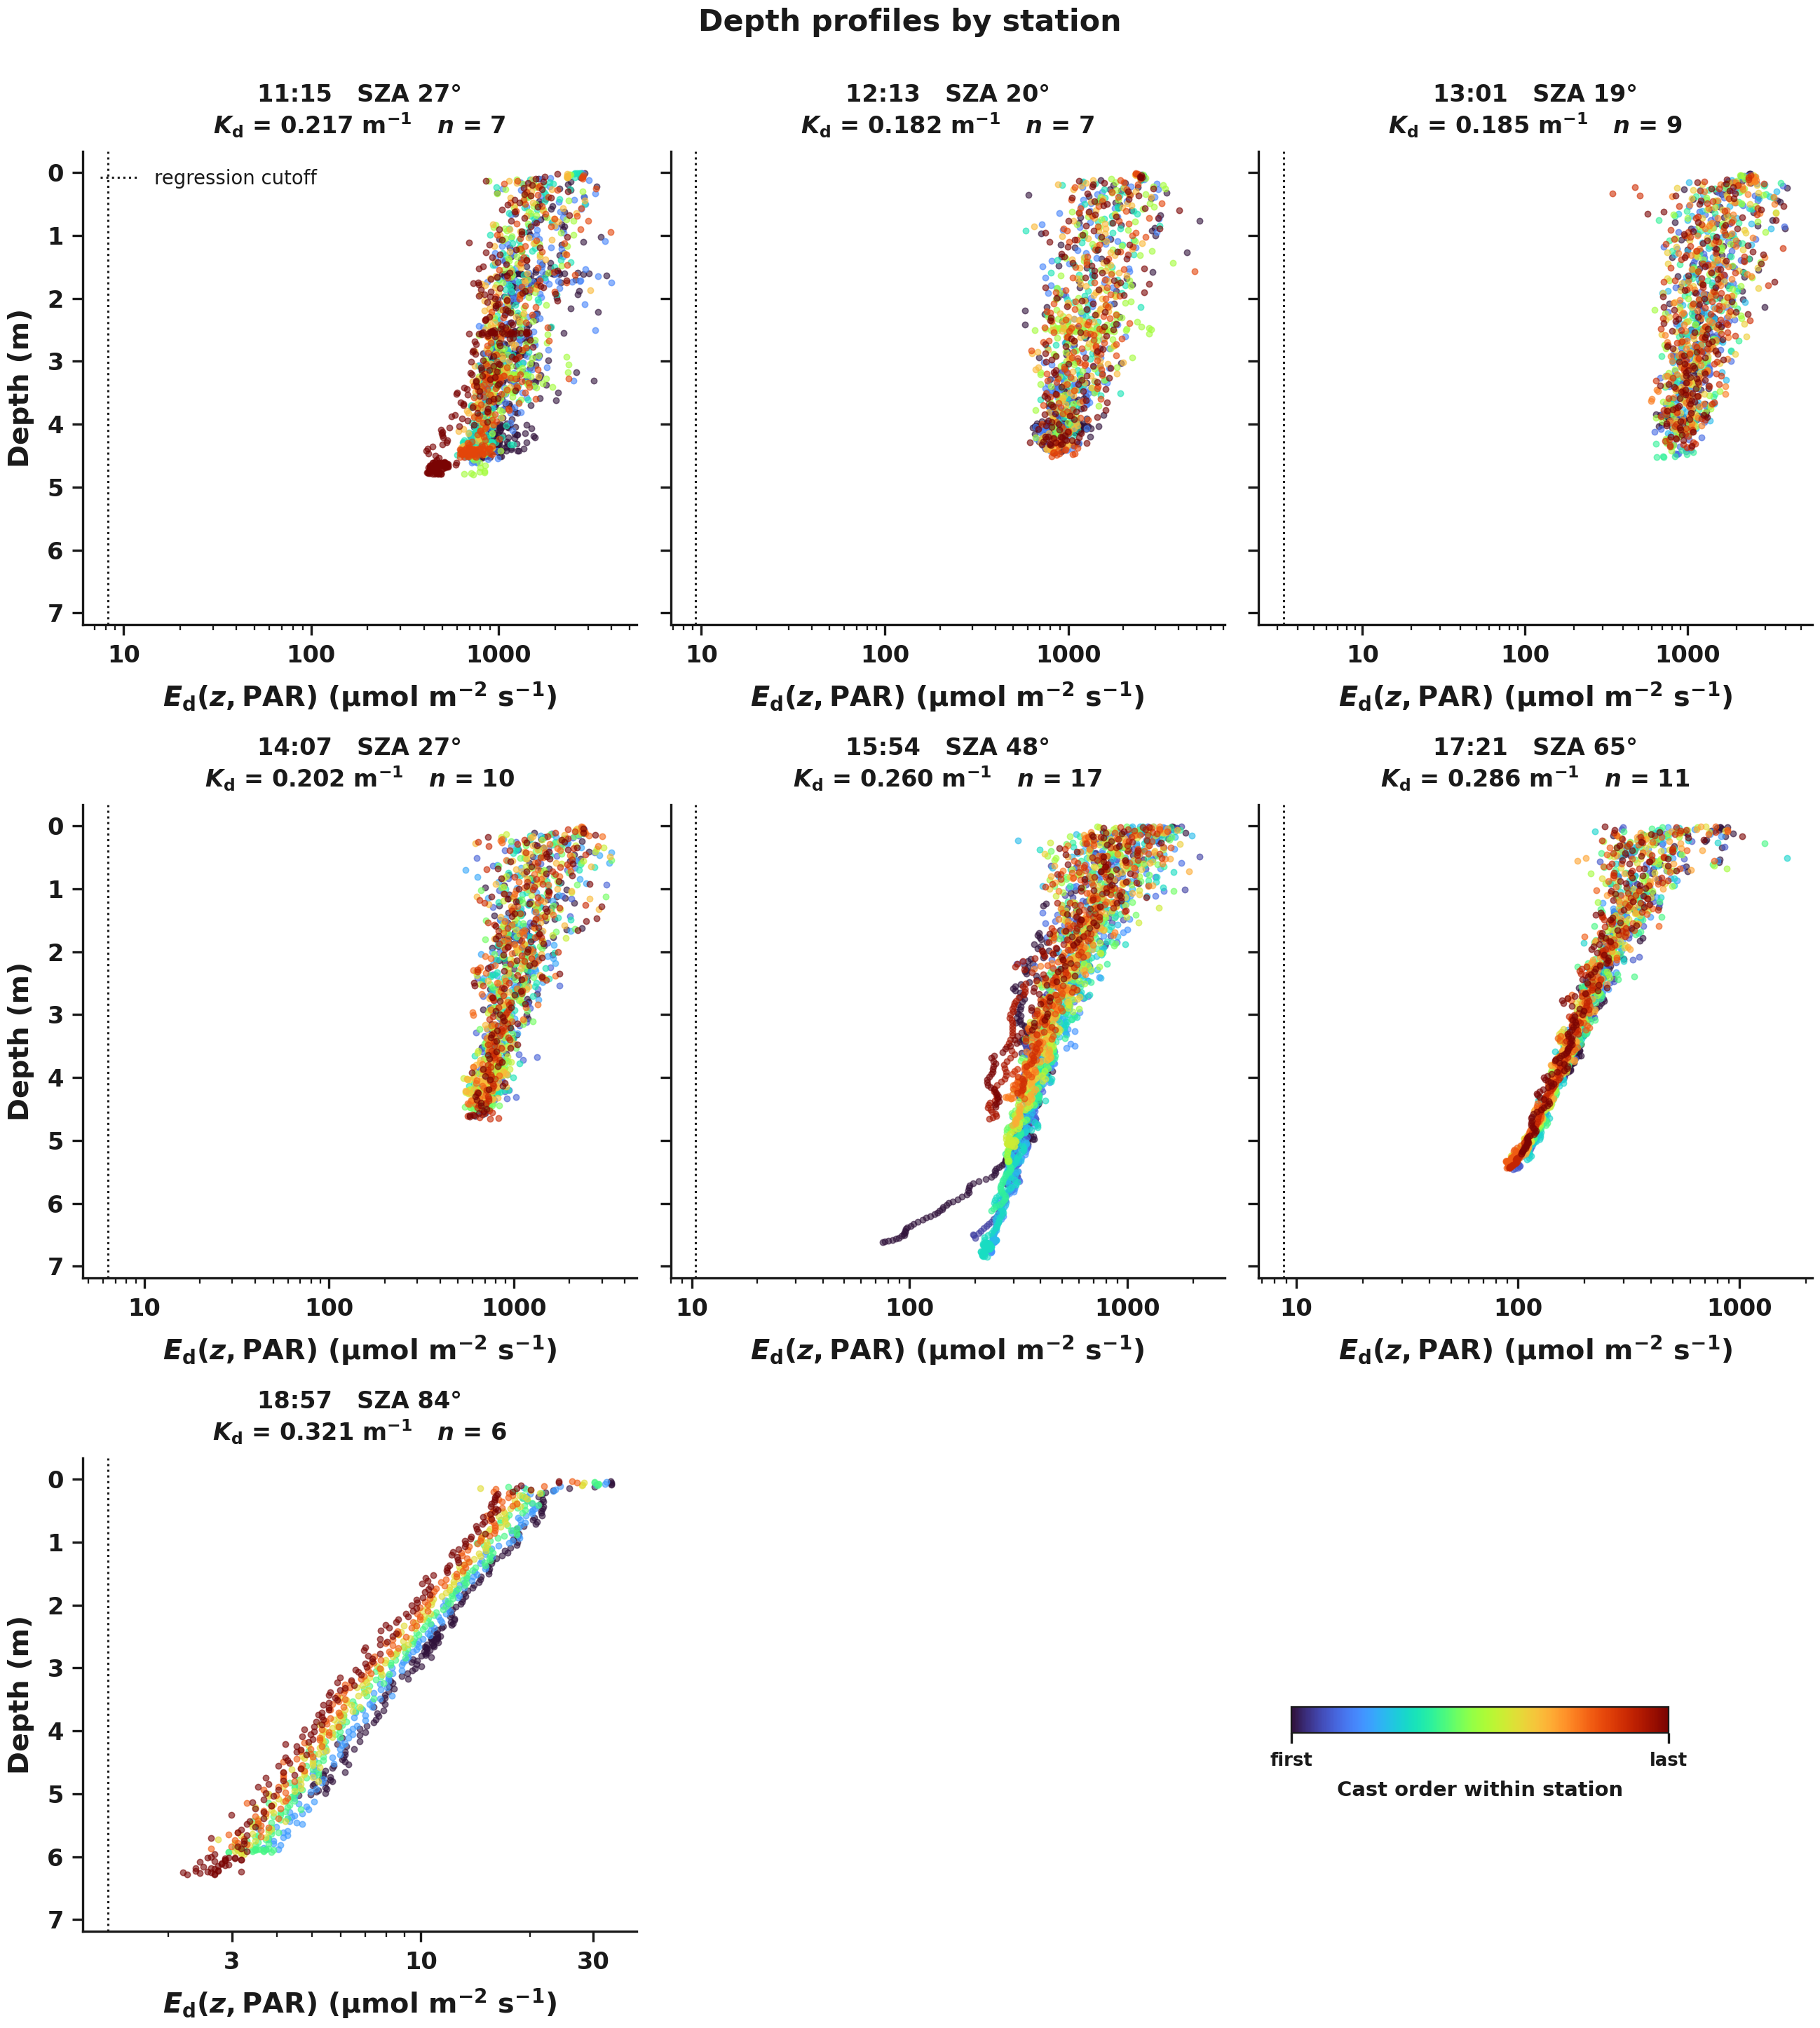

In [19]:
savefig(pio.fig_profile_grid(stations, ncol=3), "profiles"); plt.show()

## Fig 2b — depth profile by tilt

Every sample in the file on a linear axis, one figure per station. Light grey
samples fall outside a detected down cast. Cast samples at or above `TILT_OK_DEG`
are mid grey, and those below it are colored by tilt. Depth is corrected to the
dry zero, so the surface sits at 0 m as in Fig 2c.

E_dzPAR_20260811_0002  2026-08-11 11:15  7 casts
saved depth_profile_E_dzPAR_20260811_0002.png


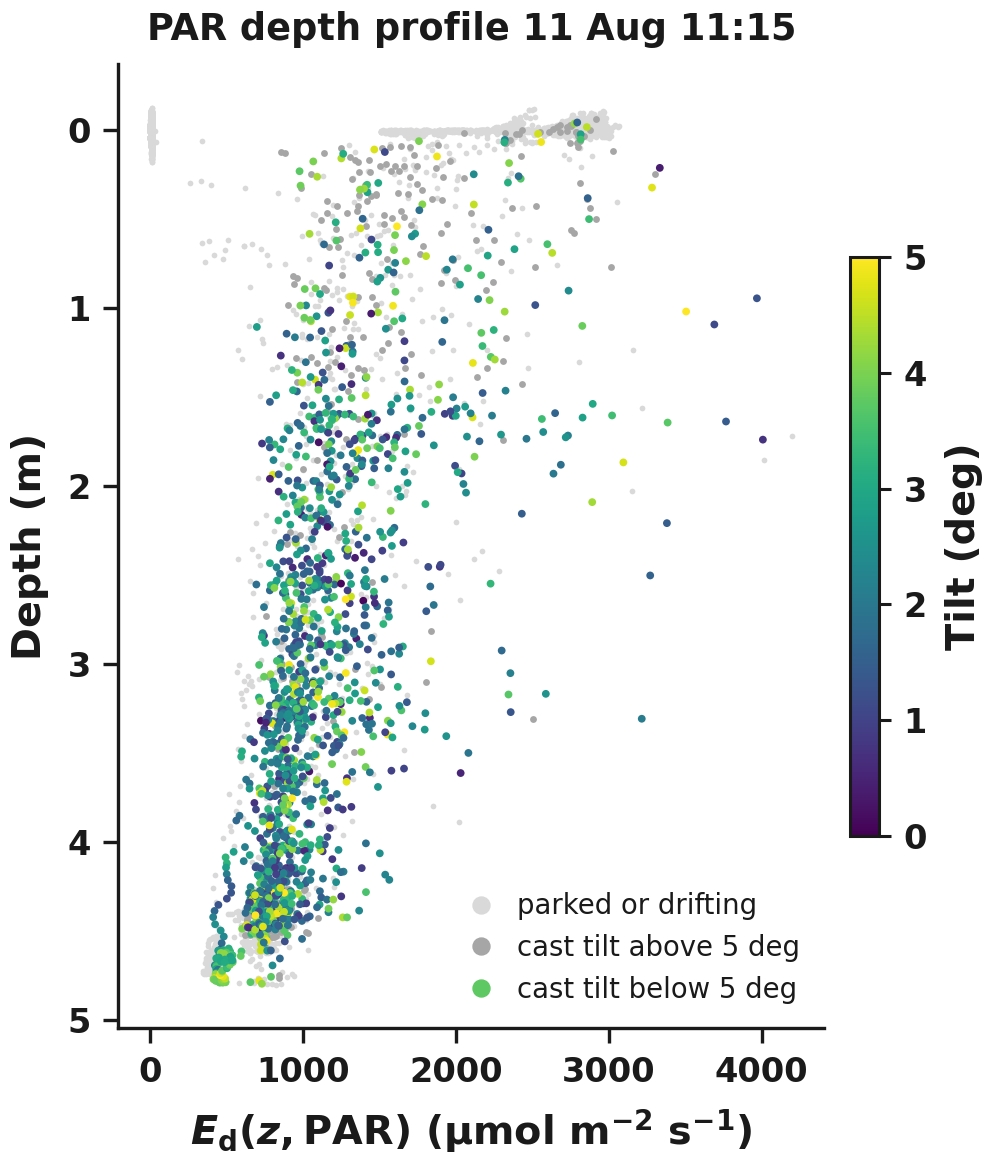

E_dzPAR_20260811_0003  2026-08-11 12:13  7 casts
saved depth_profile_E_dzPAR_20260811_0003.png


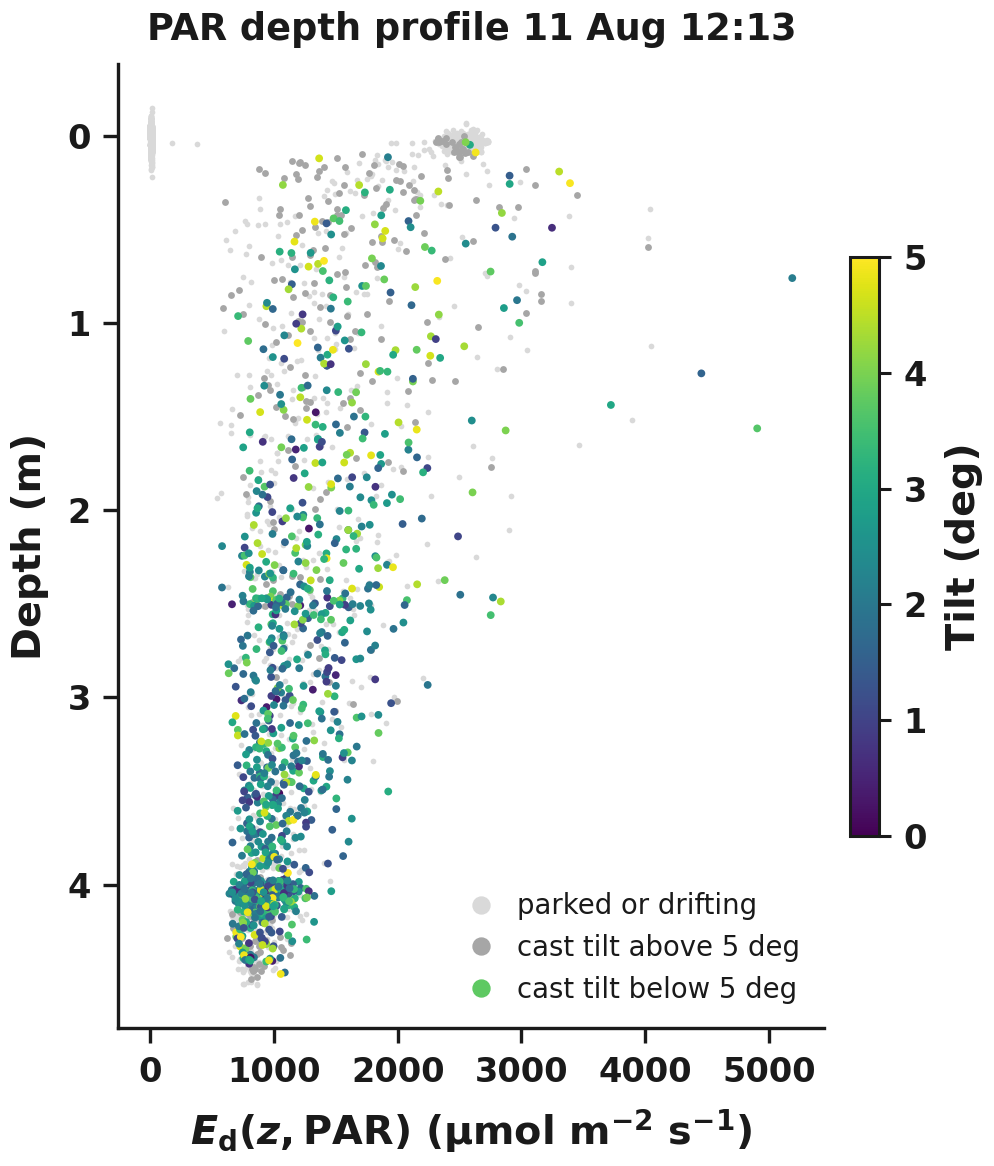

E_dzPAR_20260811_0004  2026-08-11 13:01  9 casts
saved depth_profile_E_dzPAR_20260811_0004.png


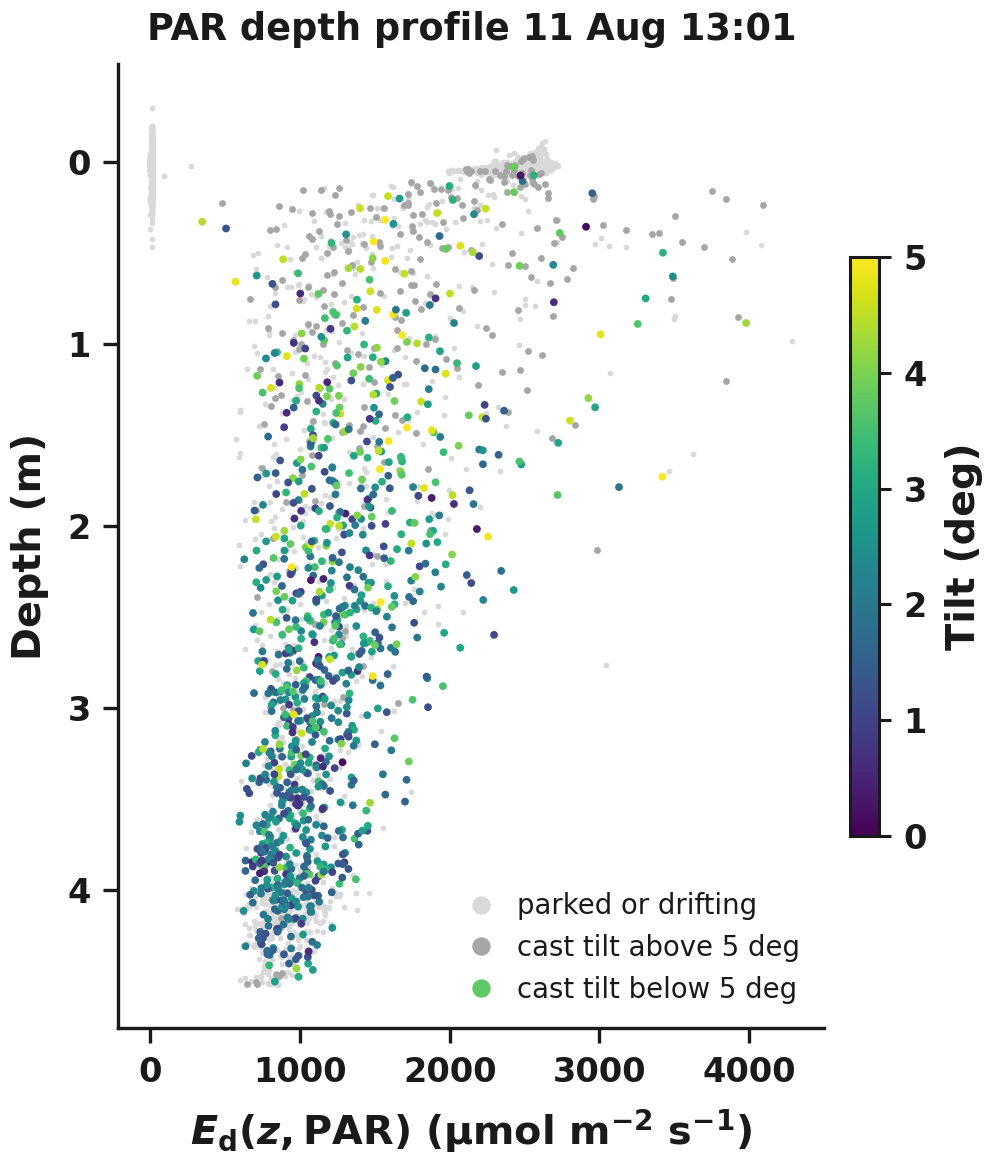

E_dzPAR_20260811_0005  2026-08-11 14:07  10 casts
saved depth_profile_E_dzPAR_20260811_0005.png


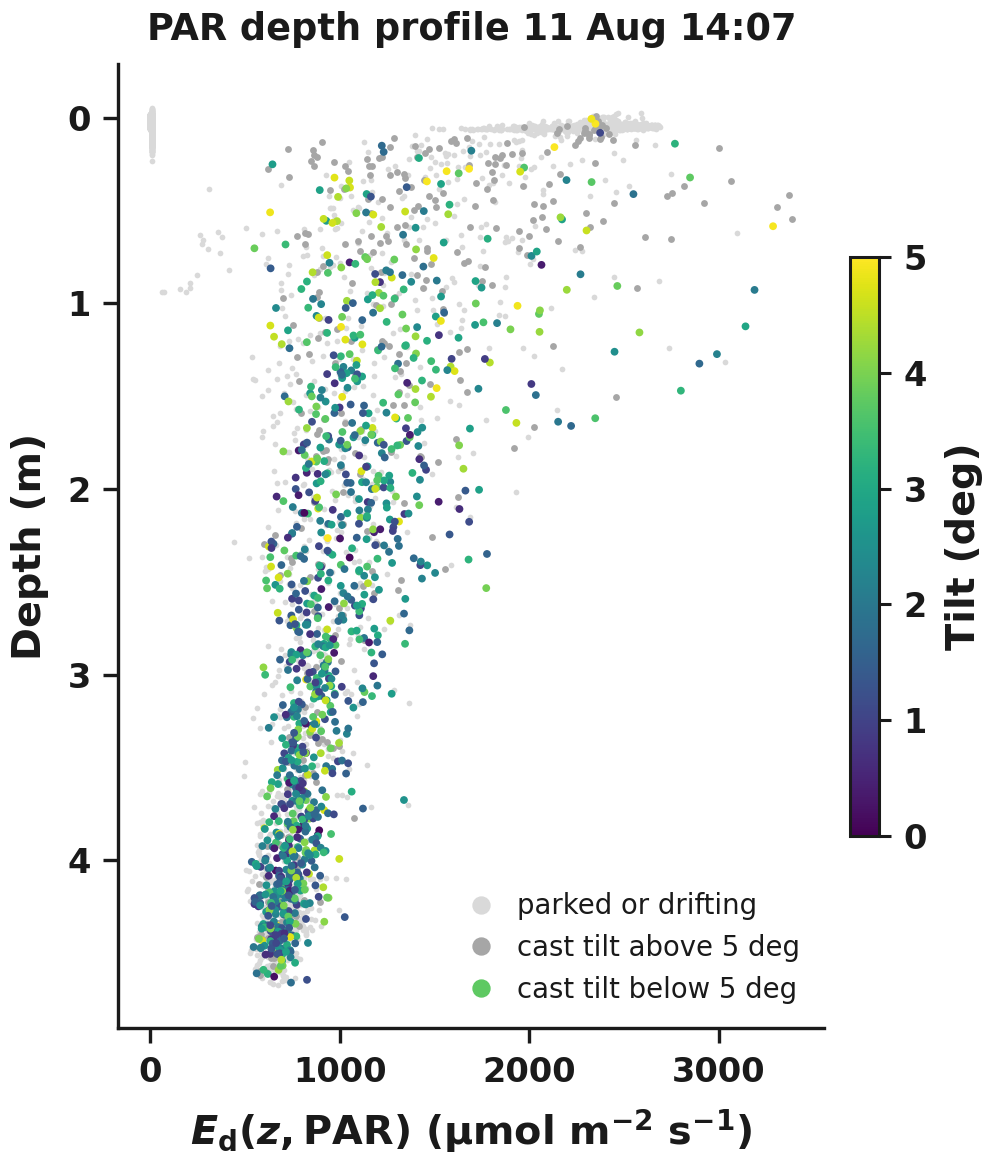

E_dzPAR_20260811_0006  2026-08-11 15:54  17 casts
saved depth_profile_E_dzPAR_20260811_0006.png


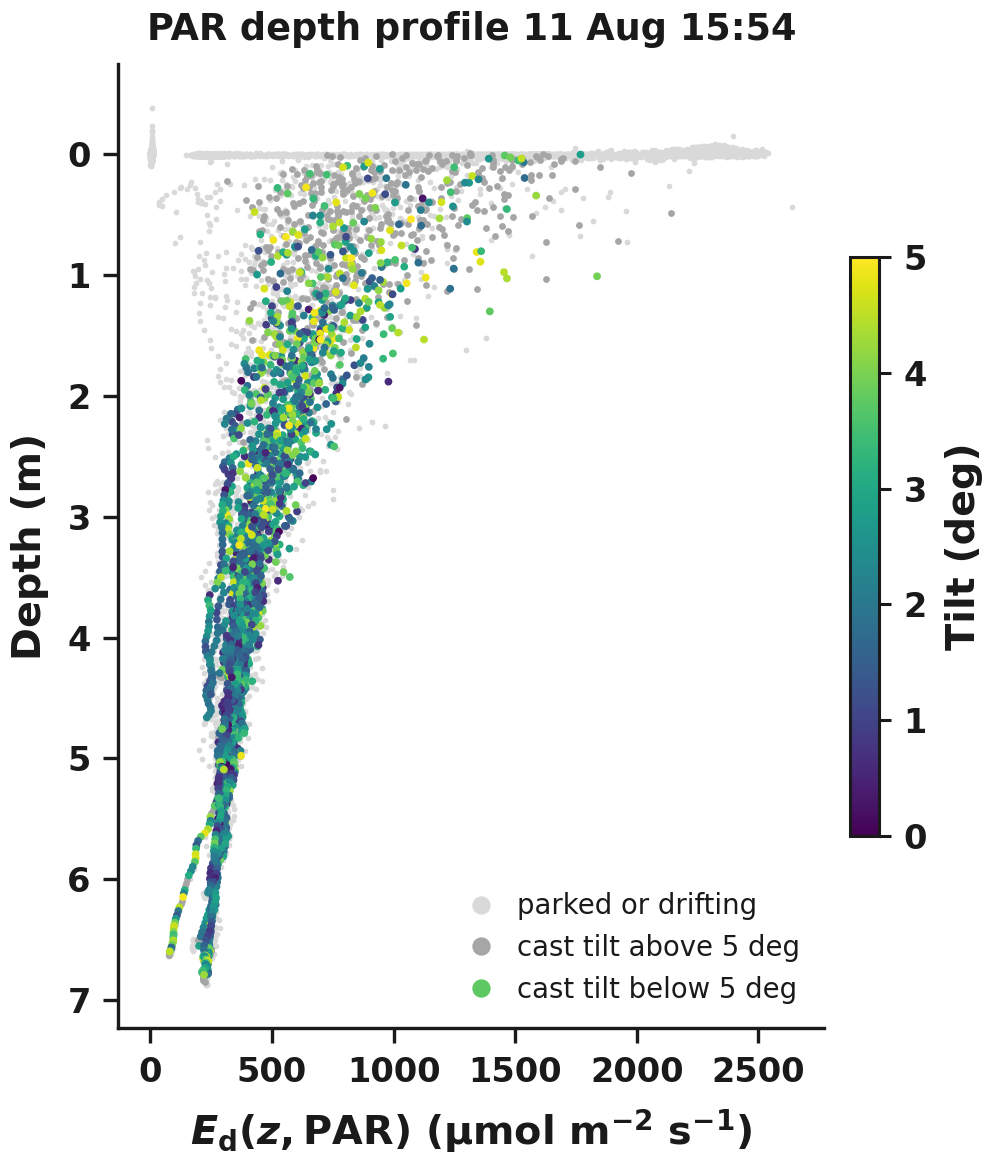

E_dzPAR_20260812_0007  2026-08-11 17:21  11 casts
saved depth_profile_E_dzPAR_20260812_0007.png


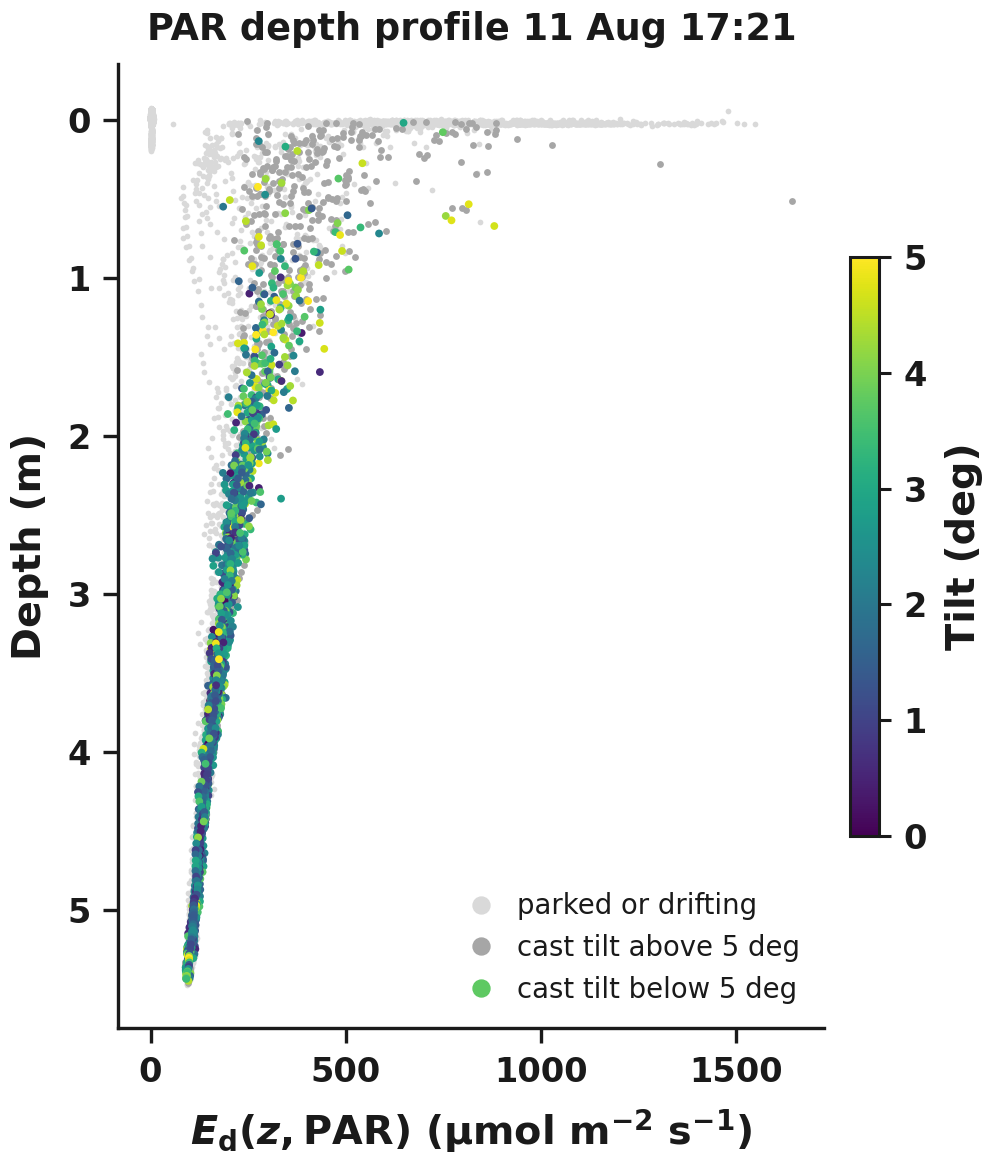

E_dzPAR_20260812_0008  2026-08-11 18:57  6 casts
saved depth_profile_E_dzPAR_20260812_0008.png


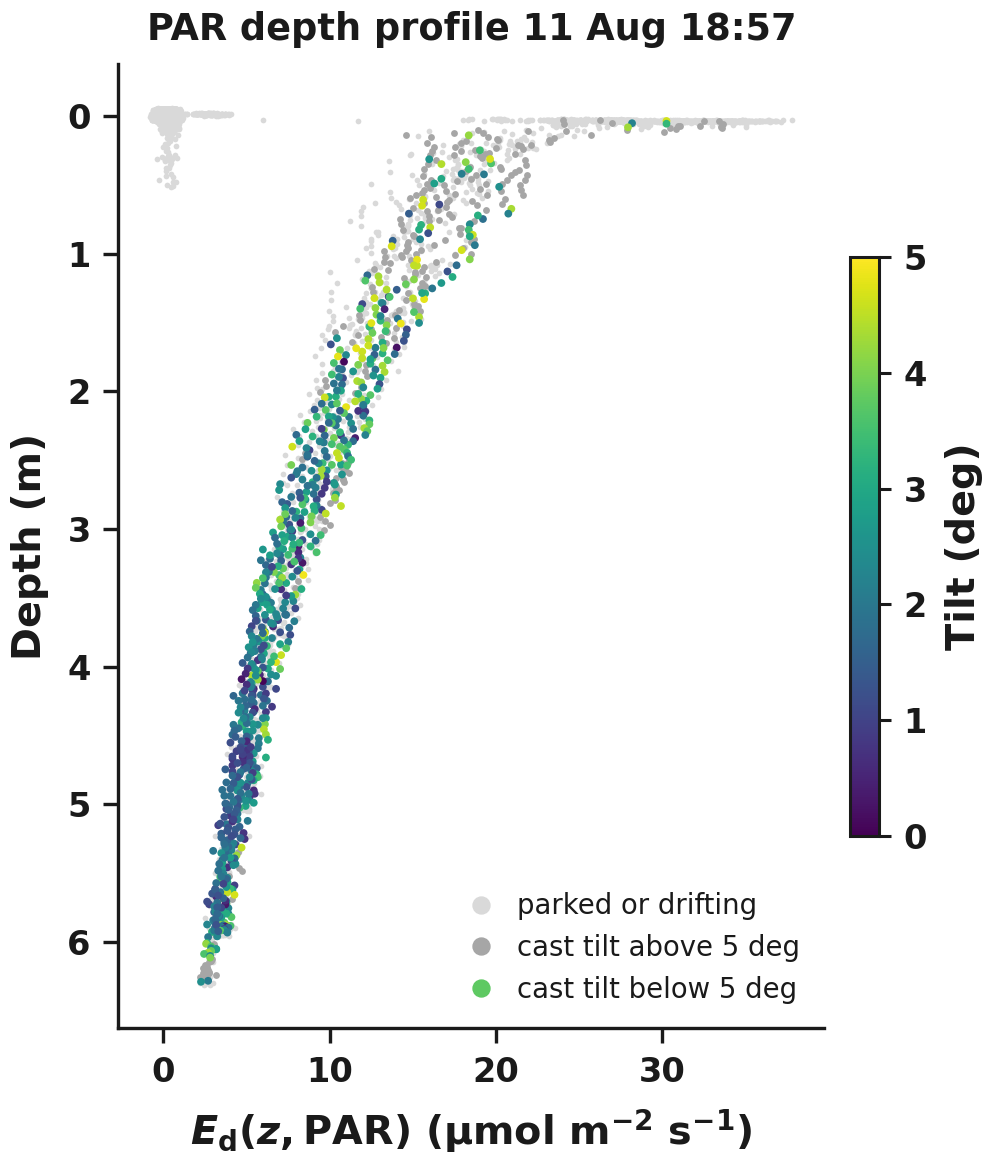

In [20]:
for s in stations:
    # named from the source file, not the clock, so two files can never collide
    print(f"{s['stem']}  {s['t0']:%Y-%m-%d %H:%M}  {len(s['casts'])} casts")
    savefig(pio.fig_depth_profile(s, TILT_OK_DEG), "depth_profile", s["stem"])
    plt.show()

## Fig 2c — log profile and ADS1115 resolution

One color per cast. Filled samples entered the $K_\mathrm{d}$ fit; hollow samples
are below the regression cutoff and were not fitted. The dashed line is one
ADS1115 step in $E_\mathrm{d}$ units, the resolution of the converter rather than
the noise floor of the SQ-500. That line is drawn only where the dimmest sample
comes within a decade of it; in clear water at 16x oversampling it sits two or
three decades below the data and would stretch the axis. `show_step=True` forces
it on, `show_cutoff=True` adds the regression cutoff.

E_dzPAR_20260811_0002  ADS1115 step 0.061 µmol m⁻² s⁻¹  cutoff 8.25  0 below cutoff  0 at or below 0
saved logx_profile_E_dzPAR_20260811_0002.png


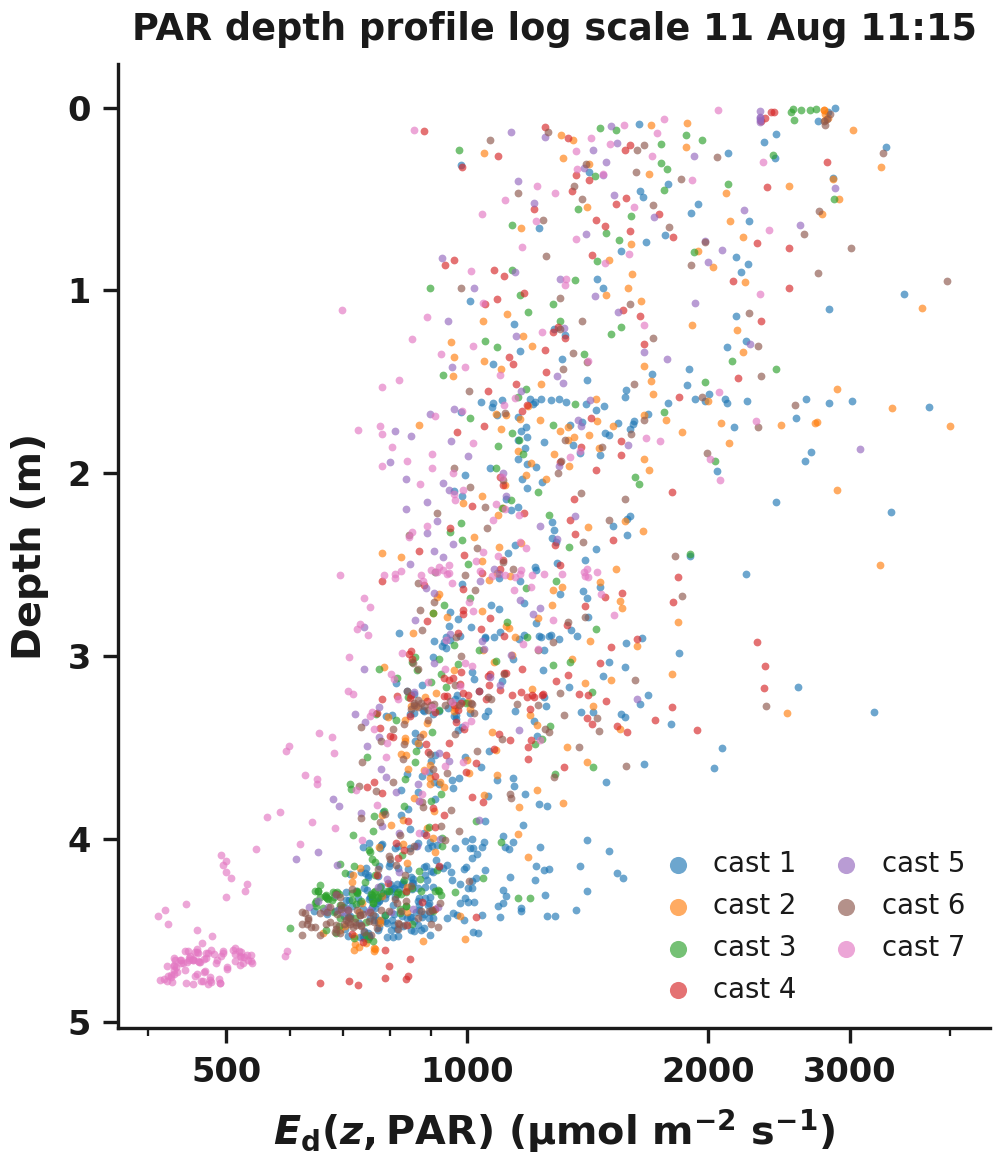

E_dzPAR_20260811_0003  ADS1115 step 0.061 µmol m⁻² s⁻¹  cutoff 9.33  0 below cutoff  0 at or below 0
saved logx_profile_E_dzPAR_20260811_0003.png


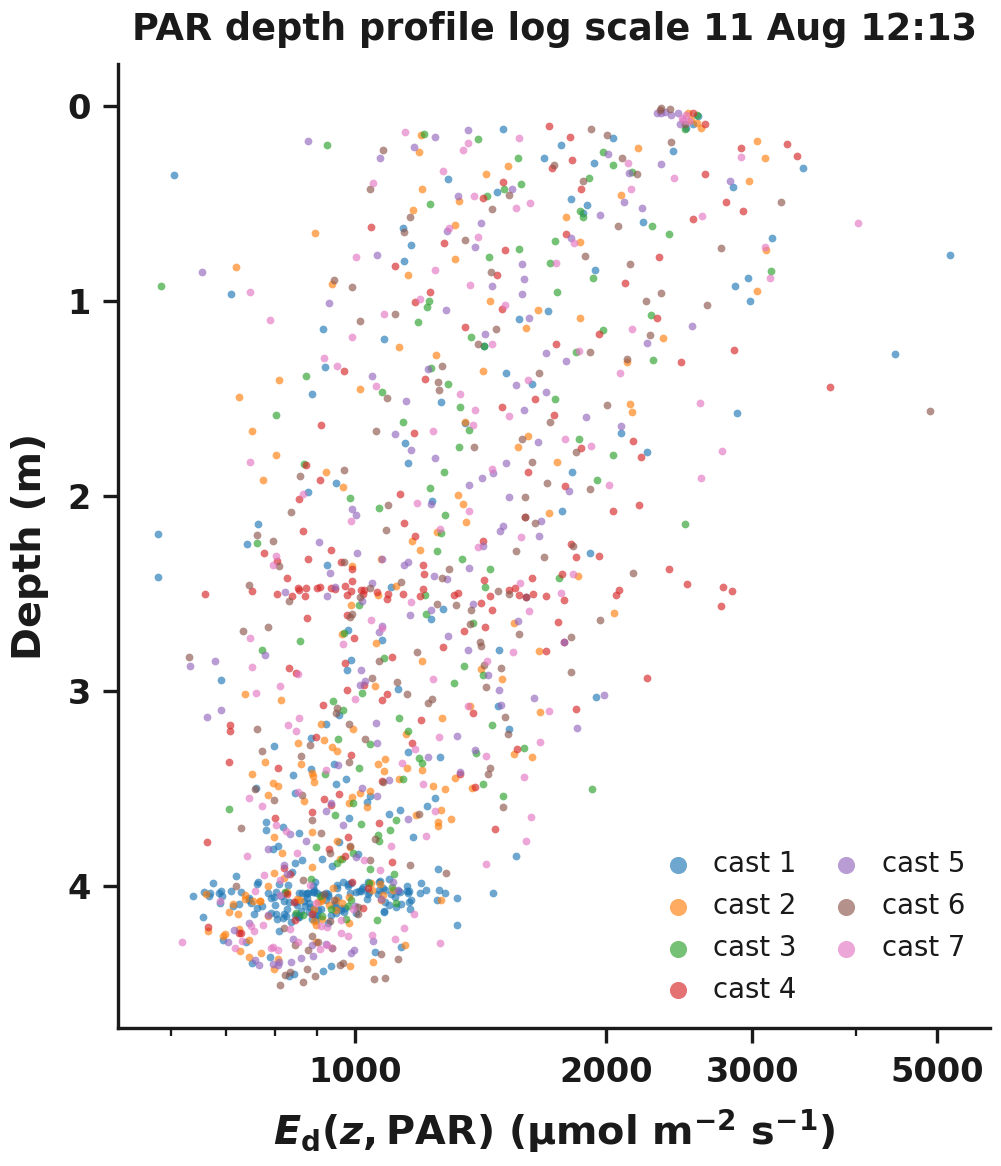

E_dzPAR_20260811_0004  ADS1115 step 0.061 µmol m⁻² s⁻¹  cutoff 3.27  0 below cutoff  0 at or below 0
saved logx_profile_E_dzPAR_20260811_0004.png


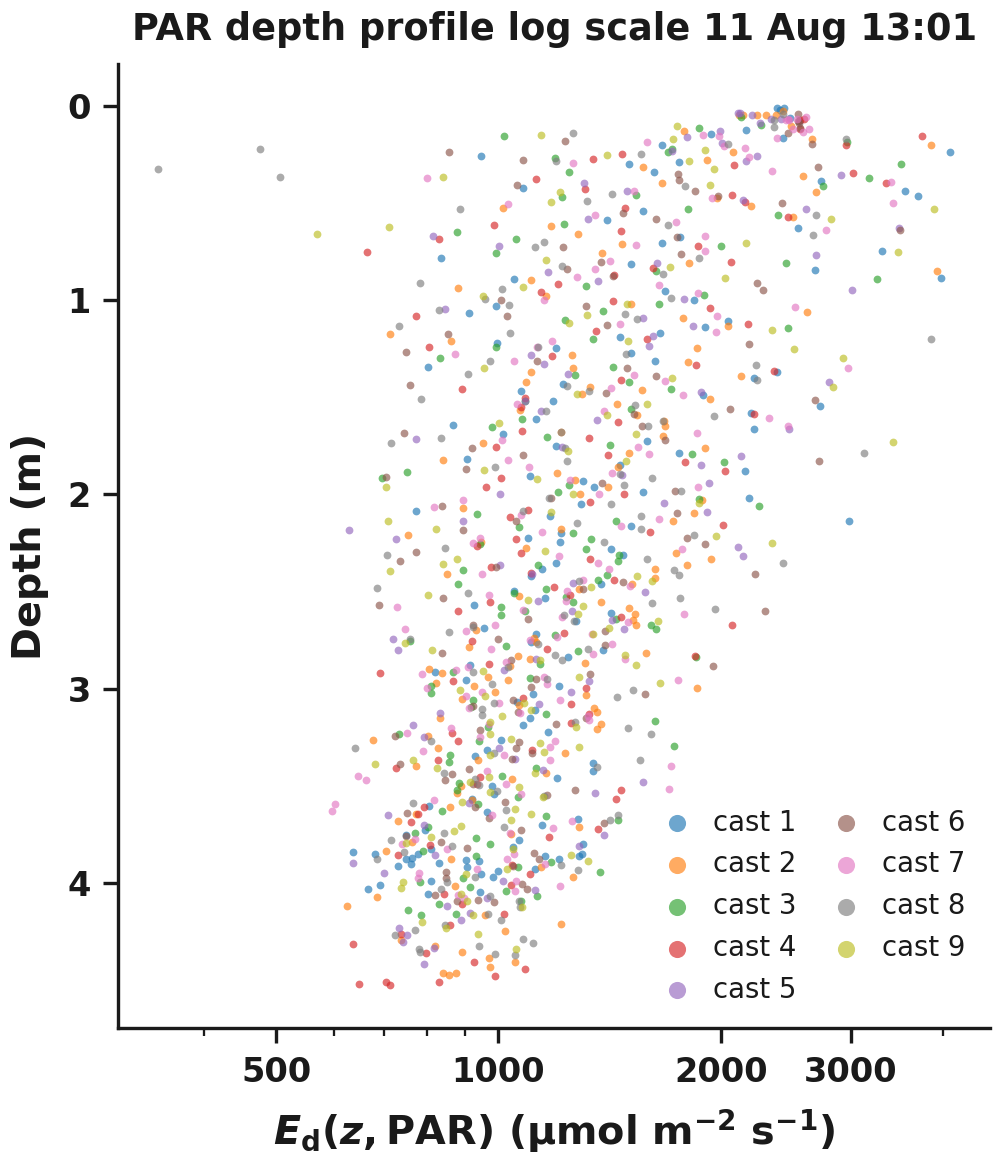

E_dzPAR_20260811_0005  ADS1115 step 0.061 µmol m⁻² s⁻¹  cutoff 6.38  0 below cutoff  0 at or below 0
saved logx_profile_E_dzPAR_20260811_0005.png


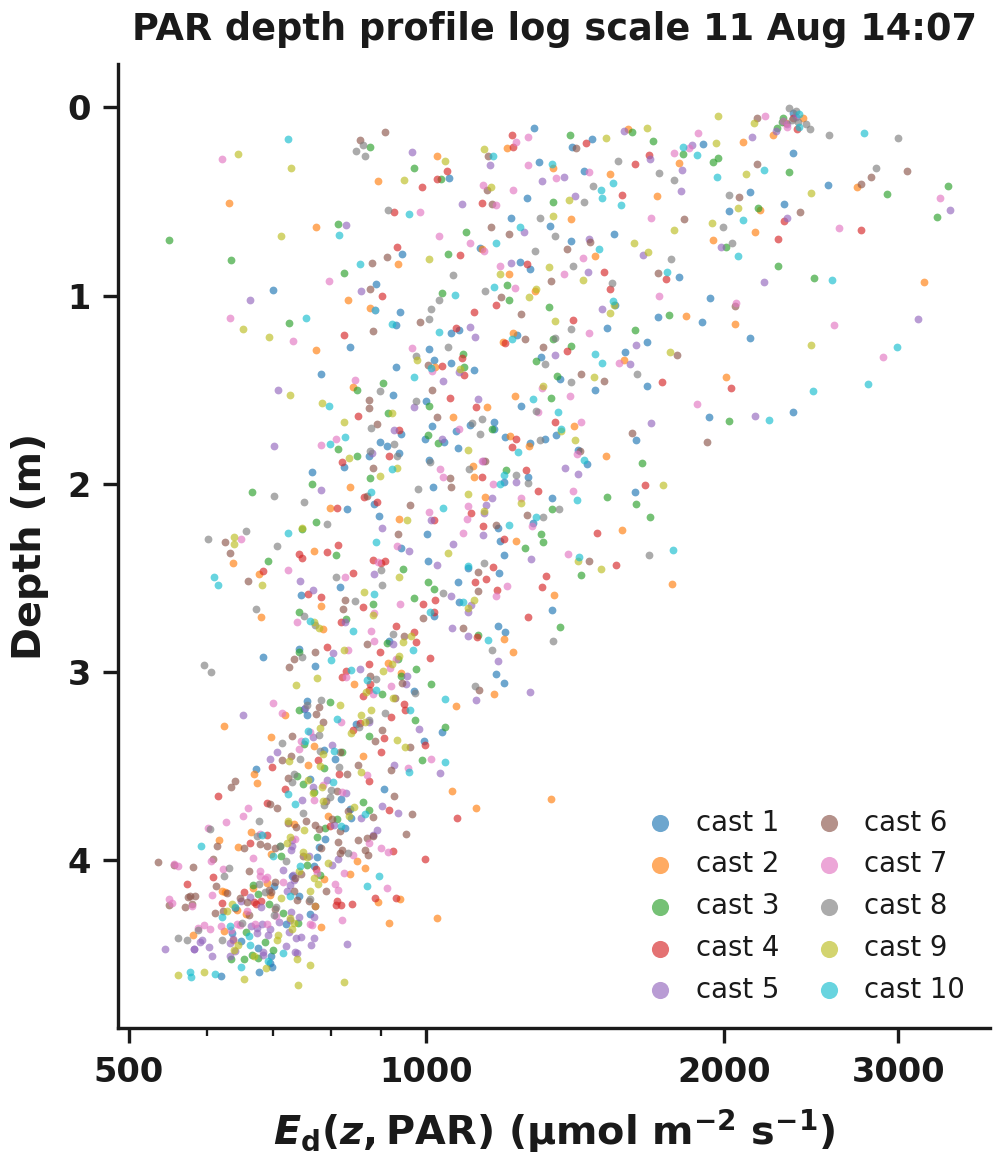

E_dzPAR_20260811_0006  ADS1115 step 0.061 µmol m⁻² s⁻¹  cutoff 10.43  0 below cutoff  0 at or below 0
saved logx_profile_E_dzPAR_20260811_0006.png


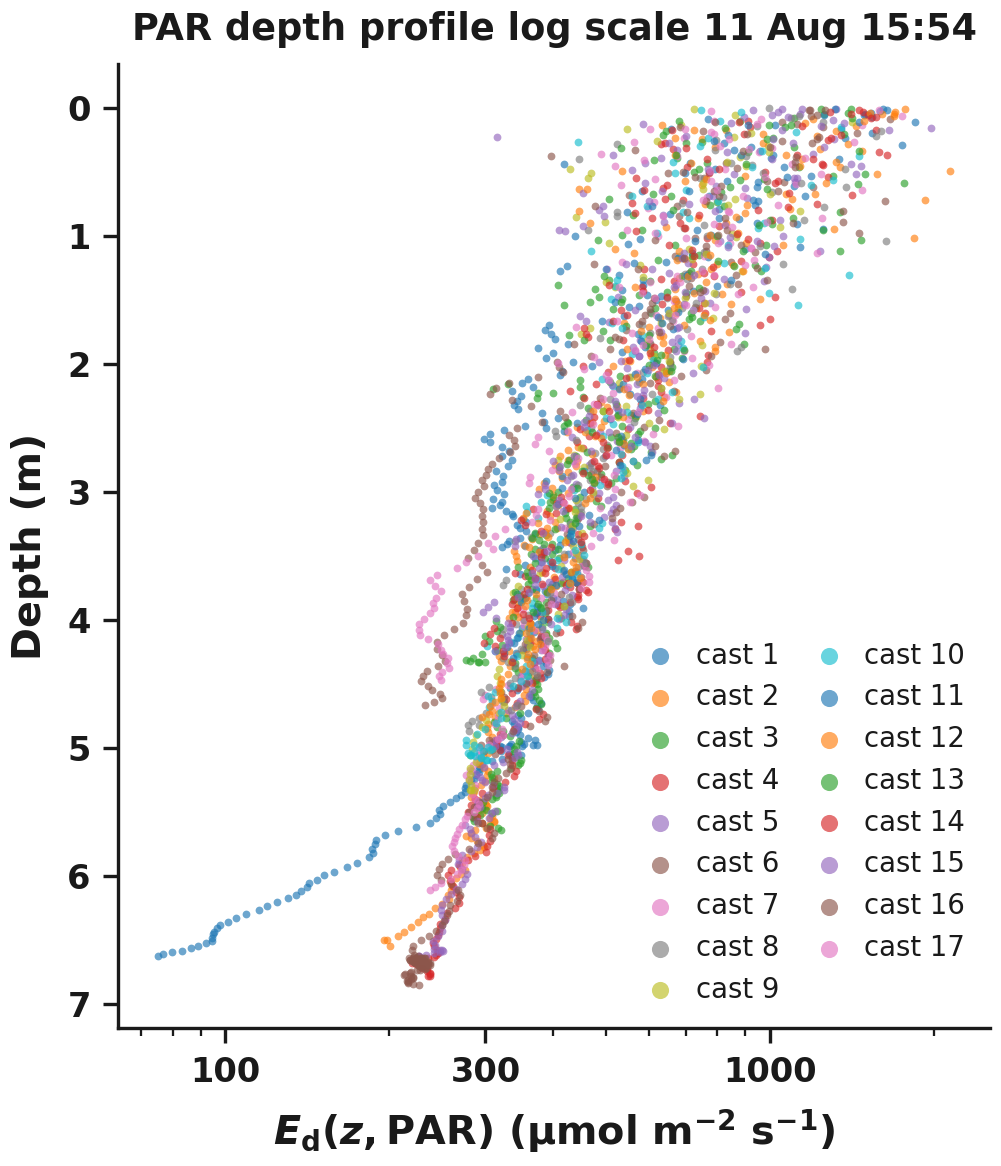

E_dzPAR_20260812_0007  ADS1115 step 0.061 µmol m⁻² s⁻¹  cutoff 8.76  0 below cutoff  0 at or below 0
saved logx_profile_E_dzPAR_20260812_0007.png


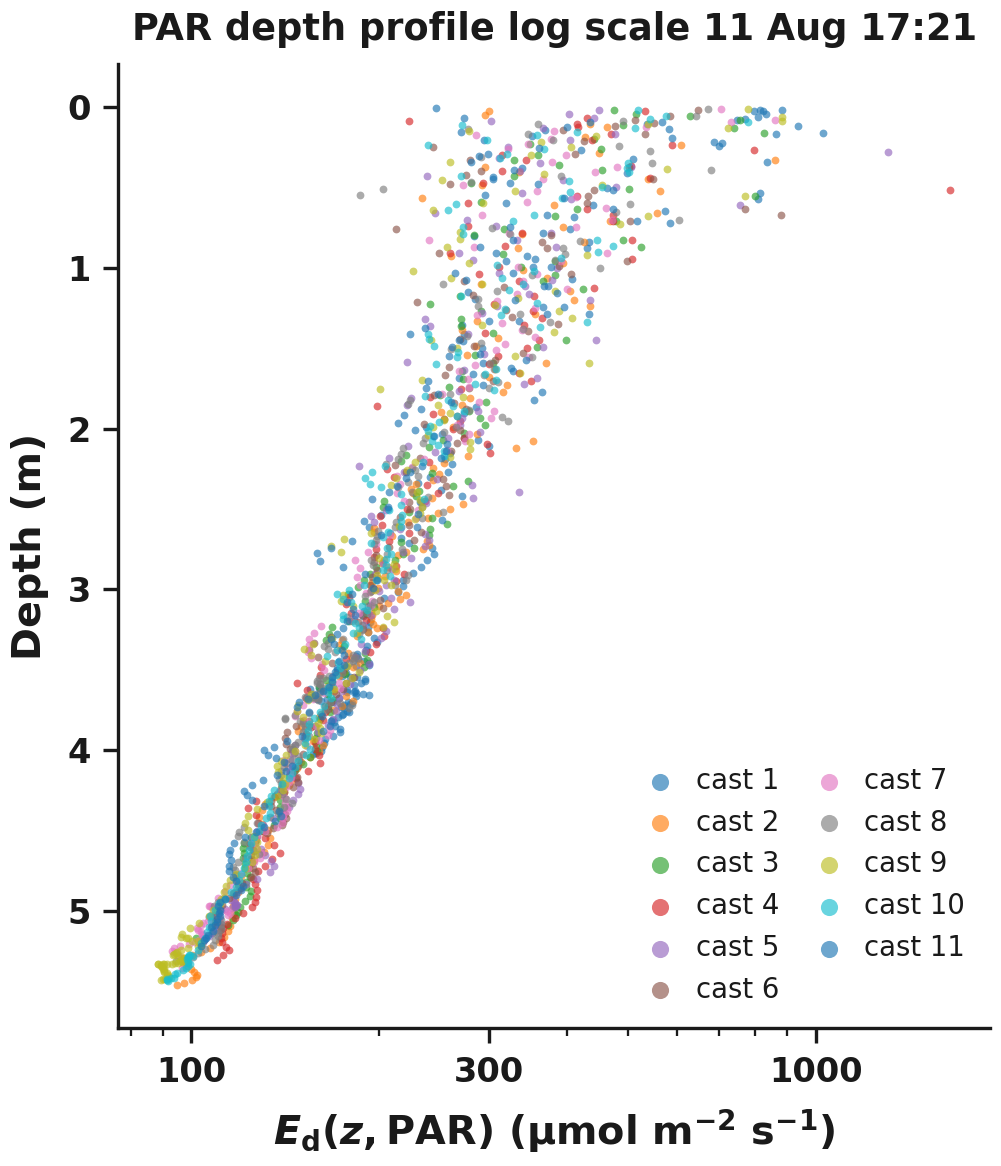

E_dzPAR_20260812_0008  ADS1115 step 0.061 µmol m⁻² s⁻¹  cutoff 1.36  0 below cutoff  0 at or below 0
saved logx_profile_E_dzPAR_20260812_0008.png


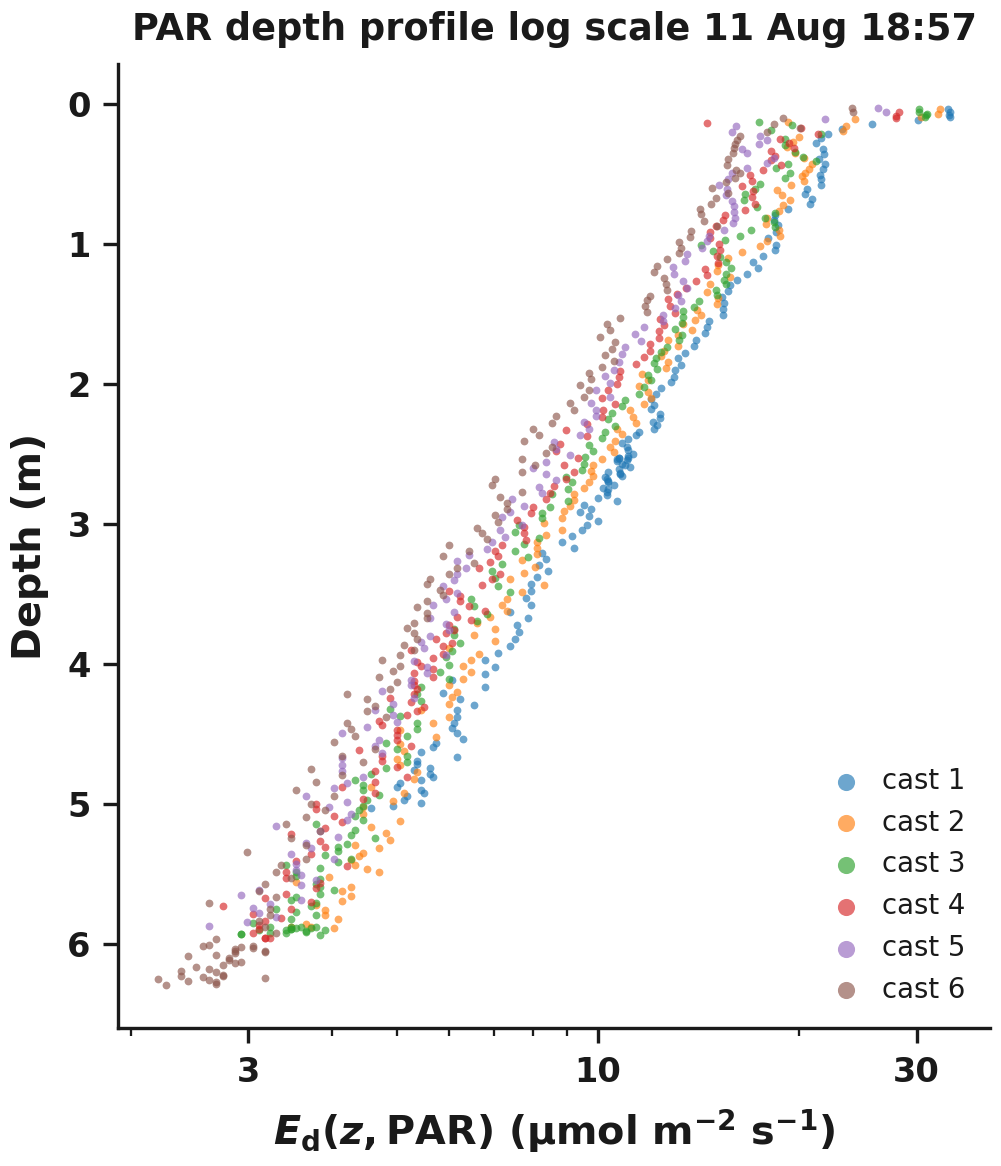

In [21]:
for s in stations:
    # samples at or below 0 cannot be drawn on a log axis, so they are counted here
    fr = pio.cast_frames(s)
    n_low = sum(int((~f.in_fit).sum()) for f in fr.values())
    n_nonpos = sum(int((f.Ed <= 0).sum()) for f in fr.values())
    print(f"{s['stem']}  ADS1115 step {pio.adc_step_ed(s):.3f} µmol m⁻² s⁻¹  "
          f"cutoff {s['min_ed']:.2f}  {n_low} below cutoff  {n_nonpos} at or below 0")
    savefig(pio.fig_logx_profile(s), "logx_profile", s["stem"])
    plt.show()

## Fig 3 — fits and residuals

The fan-out between fit lines is the honest uncertainty. Curvature in the
residuals means the decay is not exponential over that range; a flare near the
bottom is usually sand reflectance or the noise floor.

saved fits_20260811.png


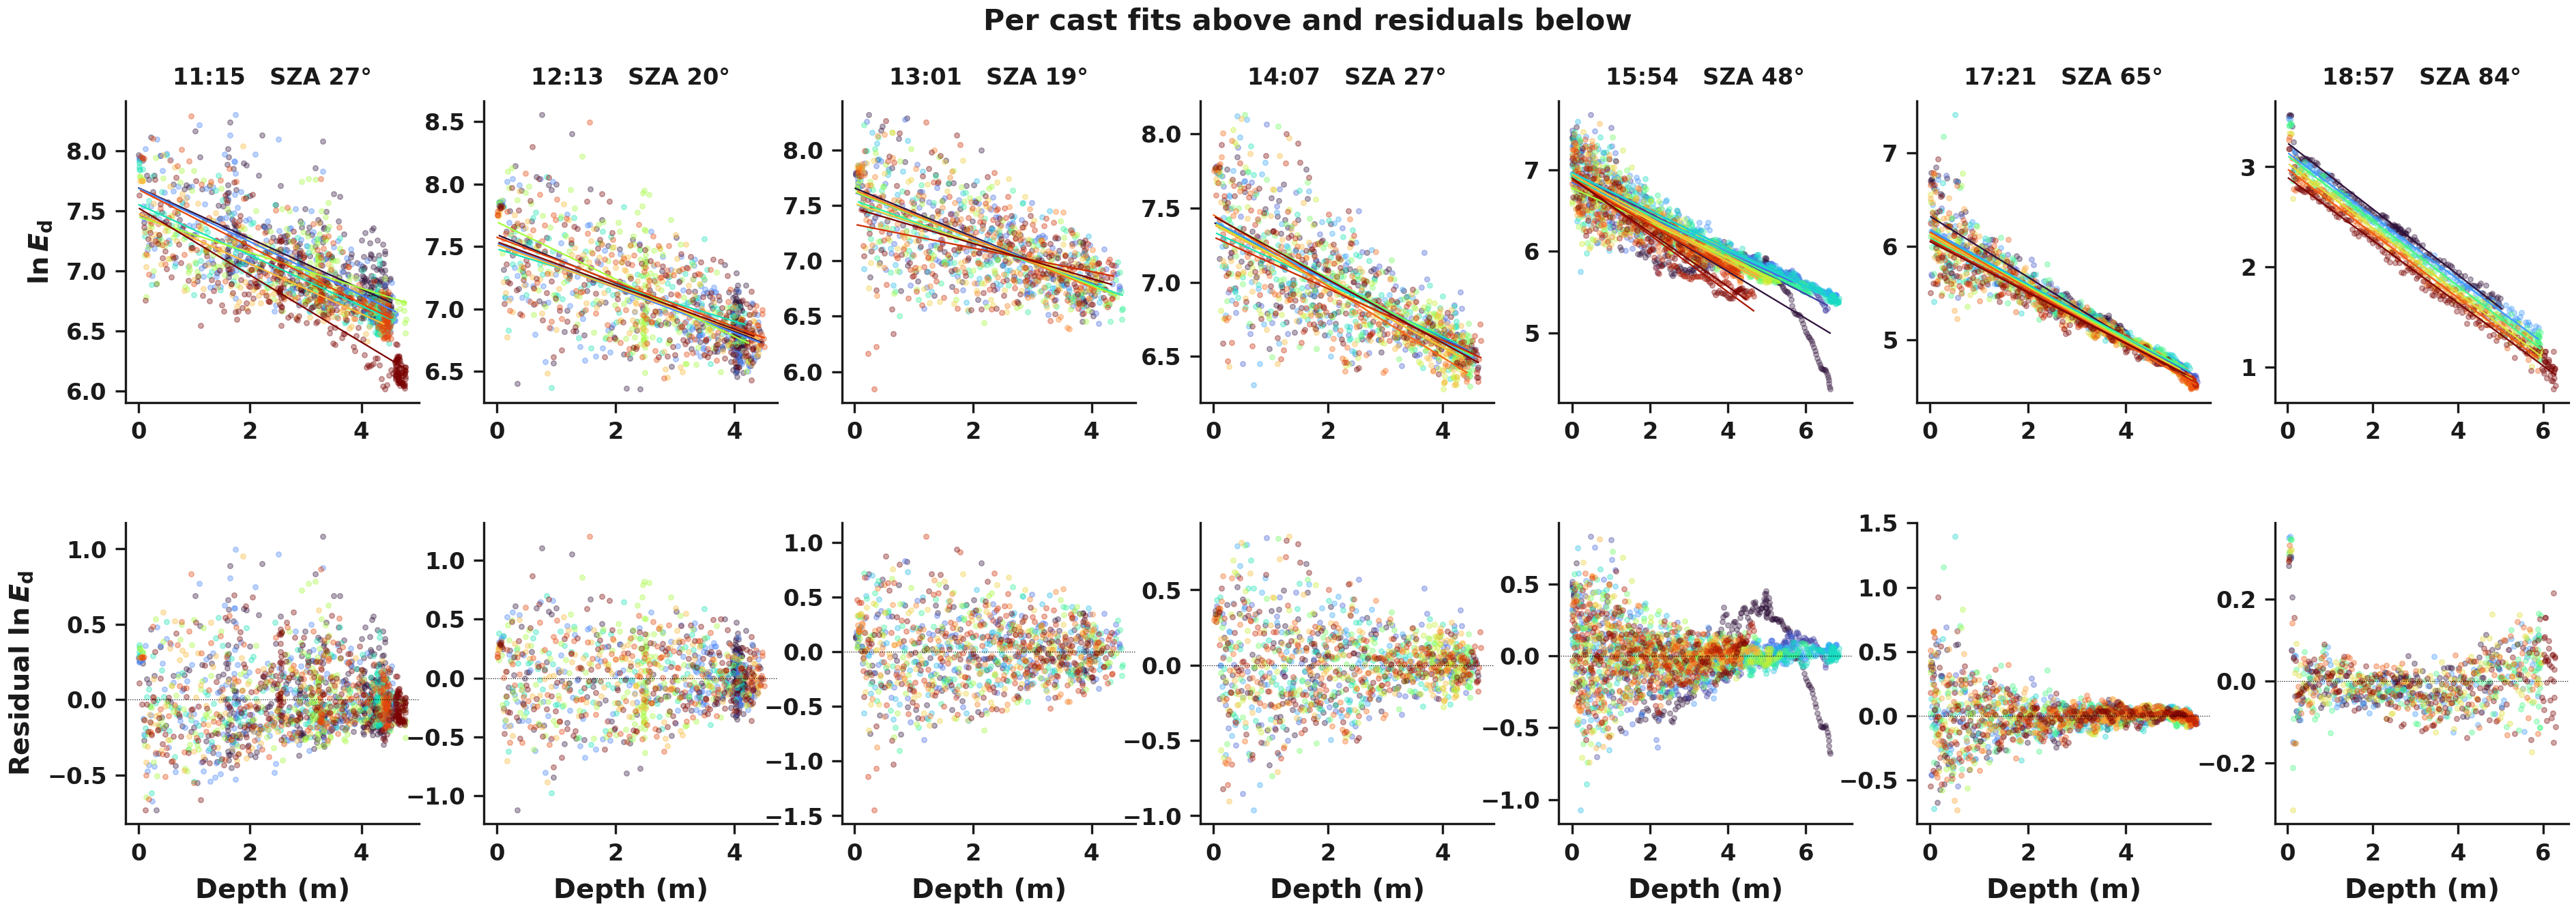

In [22]:
savefig(pio.fig_fits_grid(stations), "fits"); plt.show()

## Fig 4 — $K_\mathrm{d}$ through the day and vs sun angle

$K_\mathrm{d}$ is an *apparent* optical property: it depends on the light field as well
as the water. To first order $K_\mathrm{d}\propto 1/\cos\theta_\mathrm{w}$ (Kirk 1984) — longer
photon path per metre of depth. The dashed line is that prediction, anchored at
the station nearest solar noon; points above it need a water-column
explanation.

saved kd_time_sza_20260811.png


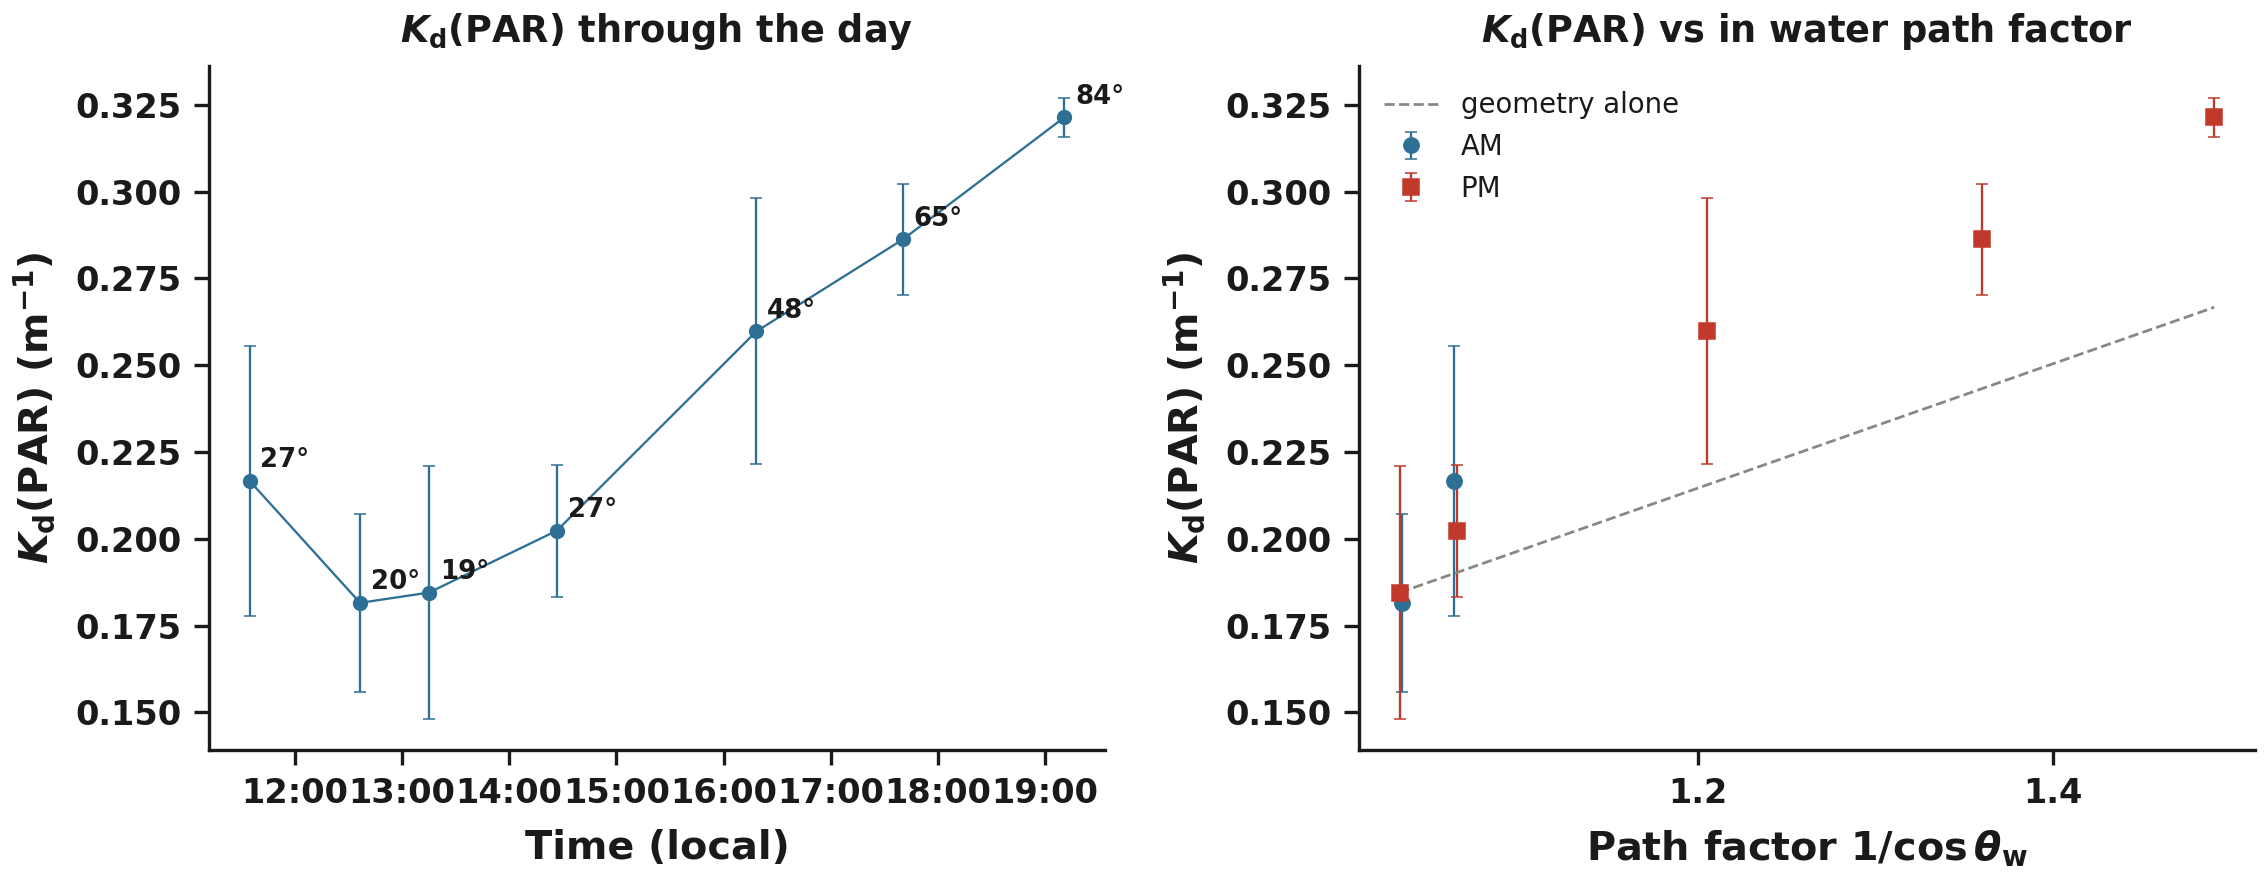

In [23]:
savefig(pio.fig_kd_day(tbl), "kd_time_sza"); plt.show()

## Fig 5 — multi-depth stations

Sun angle is constant within a station, so a difference in $K_\mathrm{d}$ between depth
groups is **not** geometric. Zaneveld et al. (2001): irradiance variance peaks
in the near-surface focal region and decays with depth as beams from successive
waves cross and average, so a profile truncated above that crossover is biased.

**Competing explanation:** shallower usually also means shoreward, where
resuspension is stronger. The CV-by-depth panel separates them — an optical
effect decays with depth, a turbidity gradient does not.

saved multidepth_E_dzPAR_20260811_0006.png


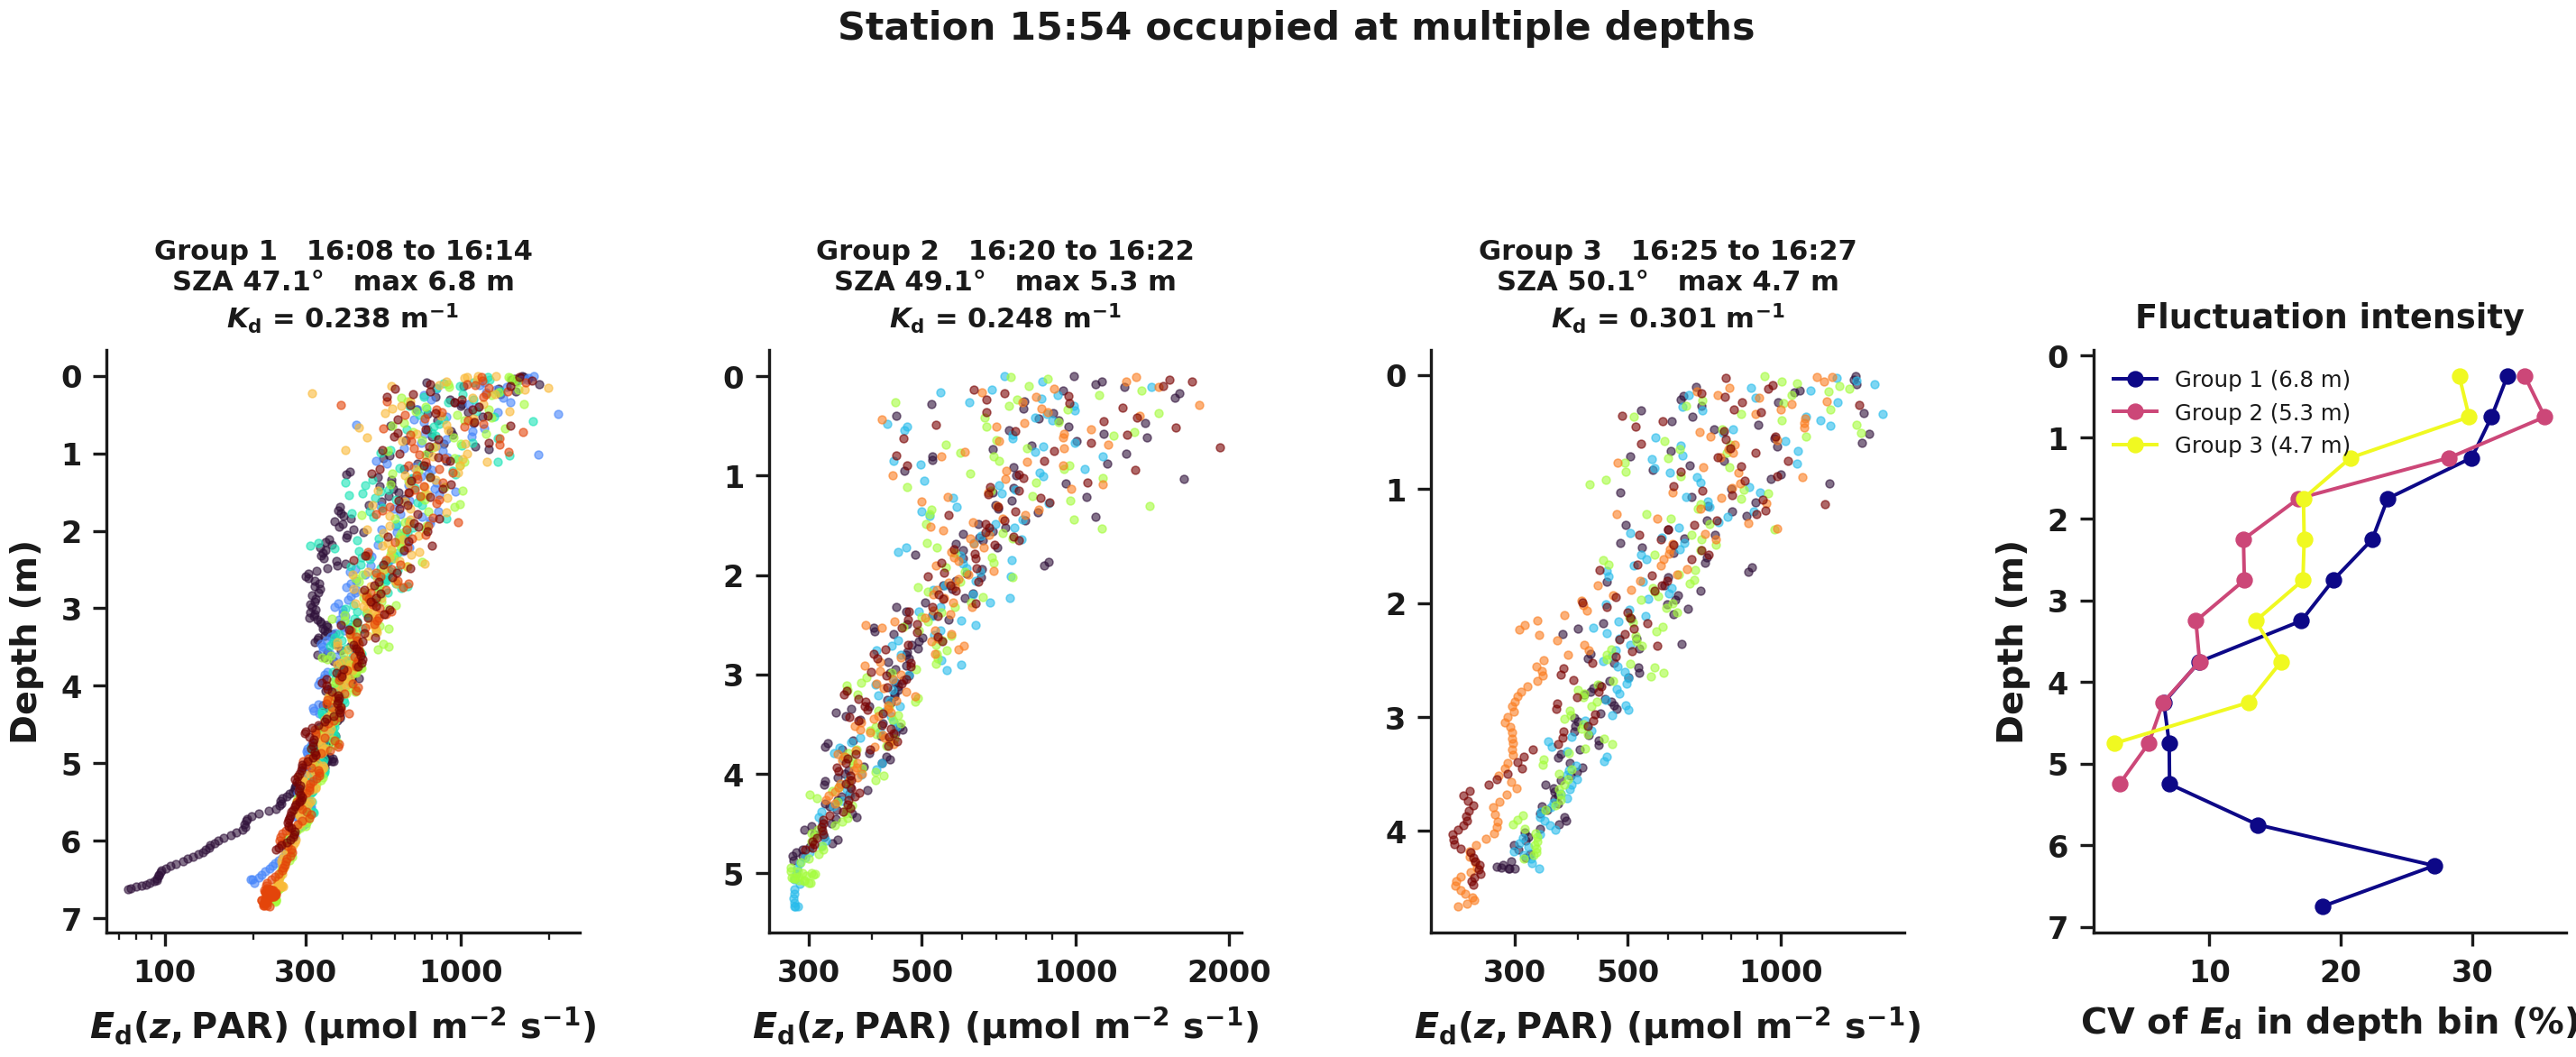

,station,group,t_start,sza,n_casts,z_max,Kd,Kd_sd,cv,r2_min,cv_upper2m
0,15:54,1,2026-08-11 16:08:48.500,47.09,7,6.85,0.2381,0.0245,10.3,0.768,29.4
1,15:54,2,2026-08-11 16:20:22.875,49.07,5,5.33,0.2485,0.0227,9.1,0.760,28.6
2,15:54,3,2026-08-11 16:25:41.000,50.12,5,4.66,0.3013,0.0364,12.1,0.773,24.2


15:54: Kd varies 27% across depth groups while SZA changes 3.0°


In [24]:
grp_all = []
for s in stations:
    fig, g = pio.fig_multidepth(s, SITE_LAT, SITE_LON, SITE_TZ, gap_min=2.0)
    if fig is None: continue
    savefig(fig, "multidepth", s["stem"]); plt.show(); grp_all.append(g)

grp = pd.concat(grp_all, ignore_index=True) if grp_all else pd.DataFrame()
if len(grp):
    display(grp)
    for st, d in grp.groupby("station"):
        if len(d) < 2: continue
        print(f"{st}: Kd varies {100*(d.Kd.max()/d.Kd.min()-1):.0f}% across depth "
              f"groups while SZA changes {d.sza.max()-d.sza.min():.1f}°")

## Fig 6 — operational range

Over what range of $\theta_\mathrm{z}$ does the instrument give repeatable observations?
Criteria were fixed in the config cell before the data were inspected.

Note $r^2$ measures how *exponential* a profile is, which under waves reflects
sea state more than instrument performance — Zaneveld found individual-profile
$K_\mathrm{d}$ deviating up to 20% with perfect instrumentation.

saved op_range_20260811.png


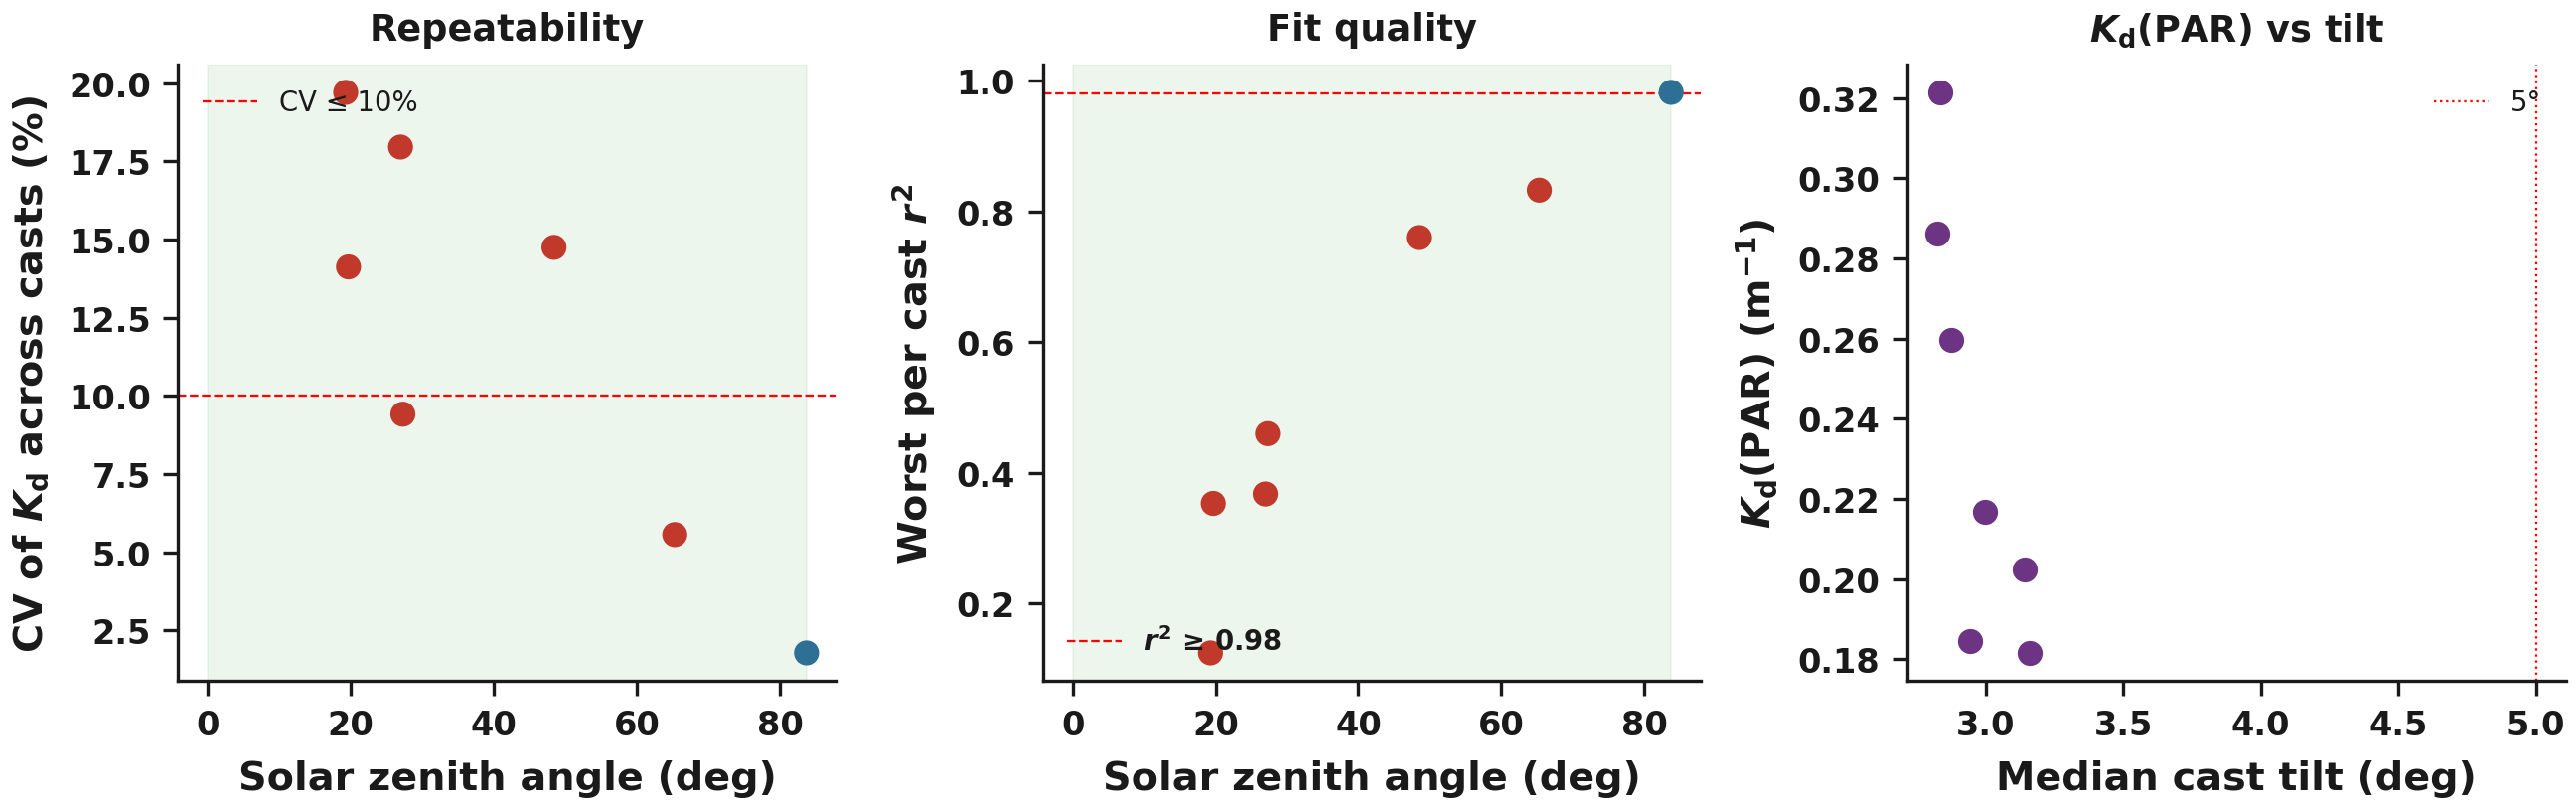

criteria: r² ≥ 0.98, CV ≤ 10%   passed 1/7
  SZA  19.3°  CV  19.7%  r² 0.125  n=9
  SZA  19.7°  CV  14.1%  r² 0.353  n=7
  SZA  26.9°  CV  18.0%  r² 0.368  n=7
  SZA  27.3°  CV   9.4%  r² 0.460  n=10
  SZA  48.4°  CV  14.7%  r² 0.760  n=17
  SZA  65.3°  CV   5.6%  r² 0.833  n=11
  SZA  83.7°  CV   1.8%  r² 0.982  n=6


In [25]:
savefig(pio.fig_operational_range(tbl, R2_MIN, CV_MAX, TILT_OK_DEG), "op_range"); plt.show()

print(f"criteria: r² ≥ {R2_MIN}, CV ≤ {CV_MAX:g}%   passed {int(tbl.ok.sum())}/{len(tbl)}")
for r in tbl.sort_values("sza").itertuples():
    print(f"  SZA {r.sza:5.1f}°  CV {r.cv:5.1f}%  r² {r.r2_min:.3f}  n={int(r.n)}")
if not (~tbl.ok).any():
    print("no station failed — report '> max SZA sampled', never 'no limit'")

## Fig 7 — wave focusing

Near-surface fluctuations are the real light field under waves, not noise:
horizontal gradients in $E_\mathrm{d}$ exceed vertical ones by an order of magnitude, so
the plane-parallel assumption behind Beer–Lambert fails for a single profile
(Zaneveld et al. 2001).

Focusing needs a **collimated beam**, so it should weaken as Fresnel reflection
removes the direct component:

$$R=\tfrac12\left(\left|\tfrac{\cos\theta_\mathrm{z}-n\cos\theta_\mathrm{w}}{\cos\theta_\mathrm{z}+n\cos\theta_\mathrm{w}}\right|^2
+\left|\tfrac{n\cos\theta_\mathrm{z}-\cos\theta_\mathrm{w}}{n\cos\theta_\mathrm{z}+\cos\theta_\mathrm{w}}\right|^2\right)$$

≈2% overhead, ≈35% at 80°, 100% at grazing.

saved focusing_20260811.png


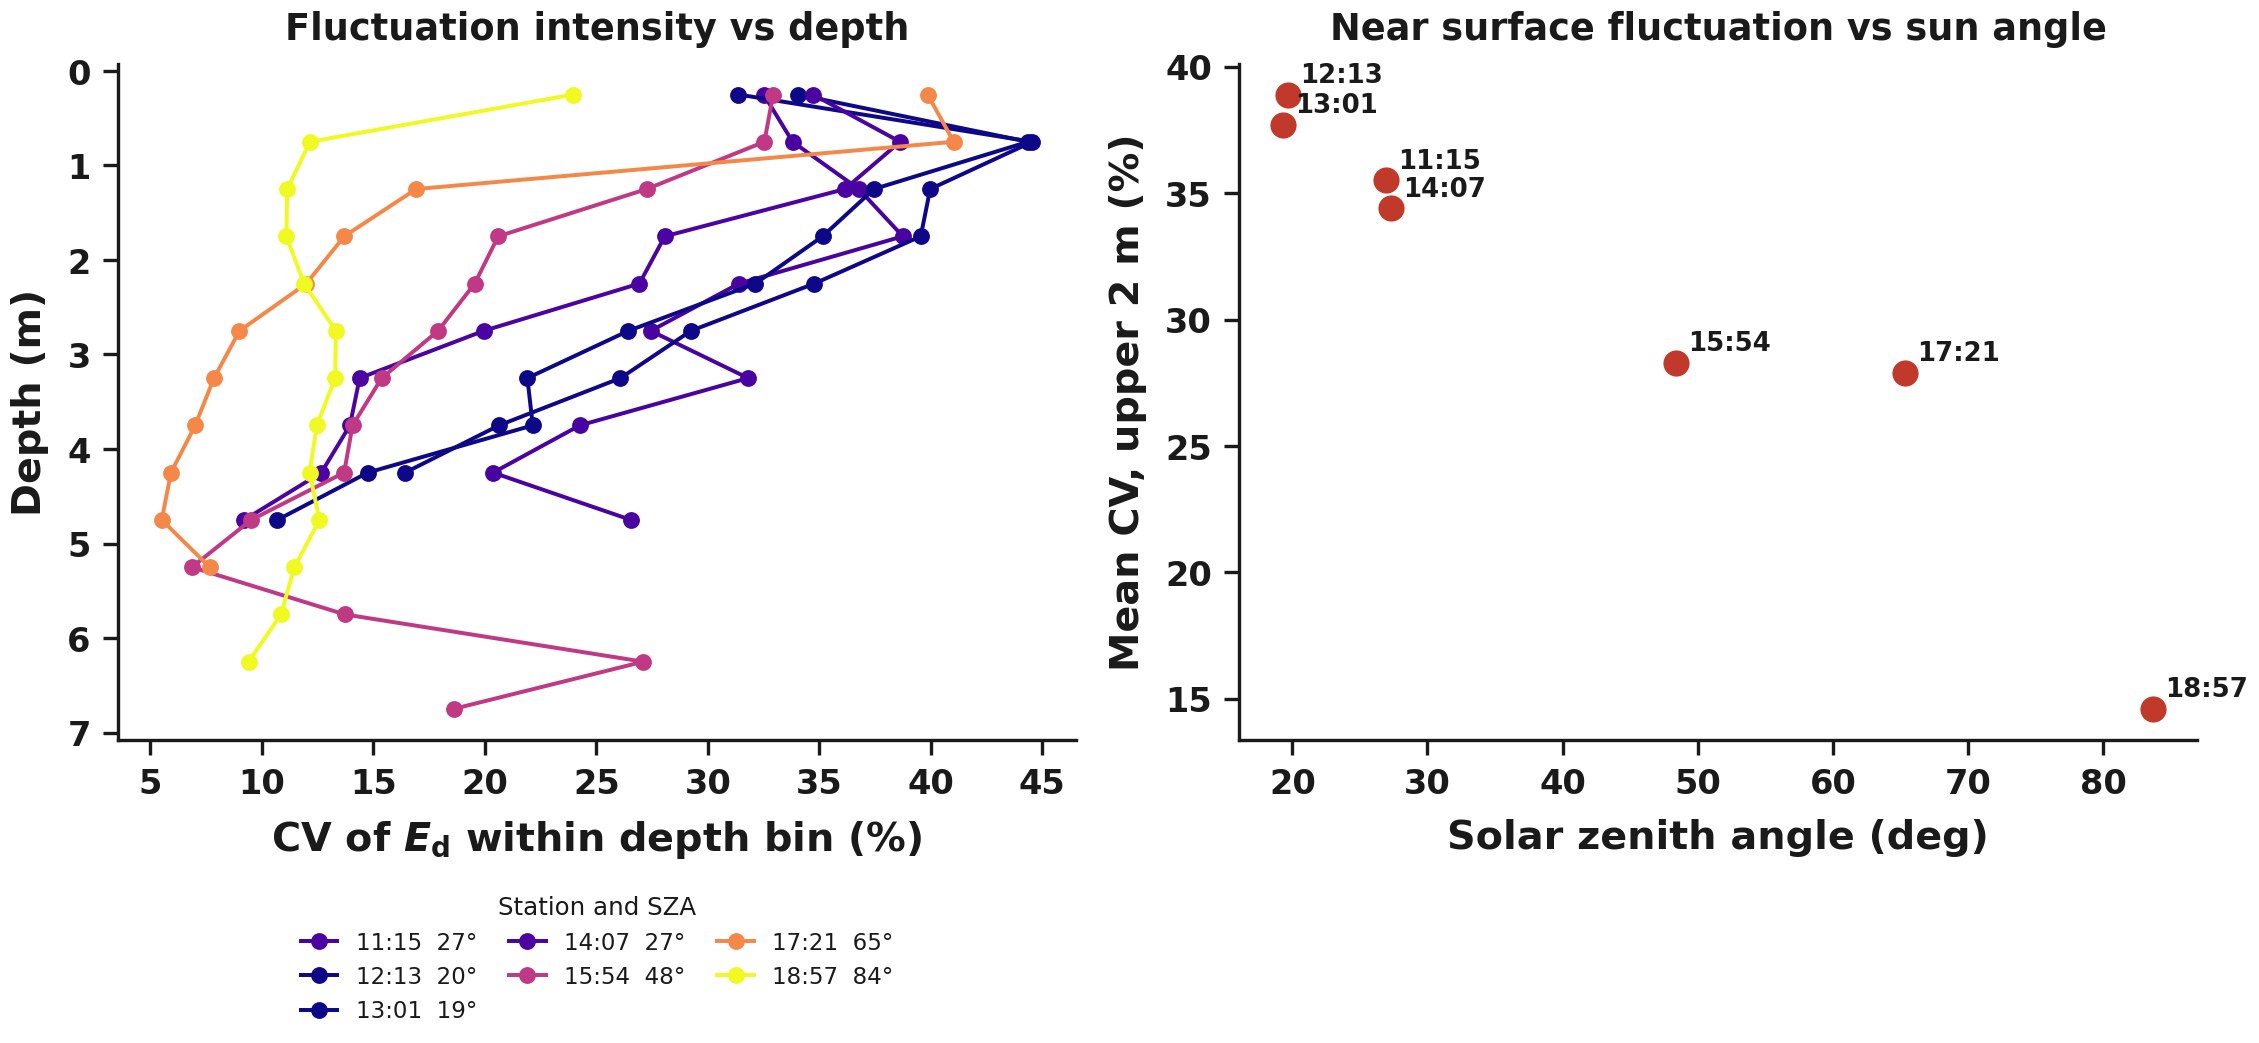

,station,sza,cv_upper2m,cv_all
0,11:15,26.9,35.5,30.4
1,12:13,19.7,38.9,31.4
2,13:01,19.3,37.7,27.9
3,14:07,27.3,34.4,23.5
4,15:54,48.4,28.3,19.3
5,17:21,65.3,27.9,15.1
6,18:57,83.7,14.6,12.7


  SZA  19.3°  ->    2.1% reflected
  SZA  19.7°  ->    2.1% reflected
  SZA  26.9°  ->    2.2% reflected
  SZA  27.3°  ->    2.2% reflected
  SZA  48.4°  ->    3.2% reflected
  SZA  65.3°  ->    9.1% reflected
  SZA  83.7°  ->   51.3% reflected


In [26]:
fig, fl = pio.fig_focusing(stations, tbl)
savefig(fig, "focusing"); plt.show()
display(fl)
for r in tbl.sort_values("sza").itertuples():
    print(f"  SZA {r.sza:5.1f}°  ->  {100*pio.fresnel_reflectance(r.sza):5.1f}% reflected")

## Fig 8 — is a correction factor warranted?

$K_\mathrm{d}$ is an *apparent* optical property. Kirk (1984) gives a leading
$1/\mu_0$ term, $\mu_0=\cos\theta_\mathrm{w}$, which is pure slant path. Gordon (1989)
showed that multiplying it out gives a quantity much closer to a property of
the water itself:

$$K_\mathrm{d}^{\text{norm}}=K_\mathrm{d}\cos\theta_\mathrm{w}=\frac{K_\mathrm{d}}{1/\cos\theta_\mathrm{w}}$$

**This is not a correction for instrument error.** It puts every cast on a
common illumination geometry so water-column change becomes visible. Note the
direction: at low sun photons travel further per metre of depth, so $K_\mathrm{d}$ reads
*high* and you divide the path factor out.

The right panel is the actual test. If the residual is flat, the Kirk model
accounts for the sun-angle dependence and **no additional correction is
warranted**. A systematic rise above some angle would be where the instrument
itself begins to fail.

Under overcast the light field is diffuse and $\mu_0$ is not set by the sun, so
the fit uses clear-sky stations where enough exist.

joined cloud index from station_sky_E_sPAR_20260811_0001.csv
saved correction_20260811.png


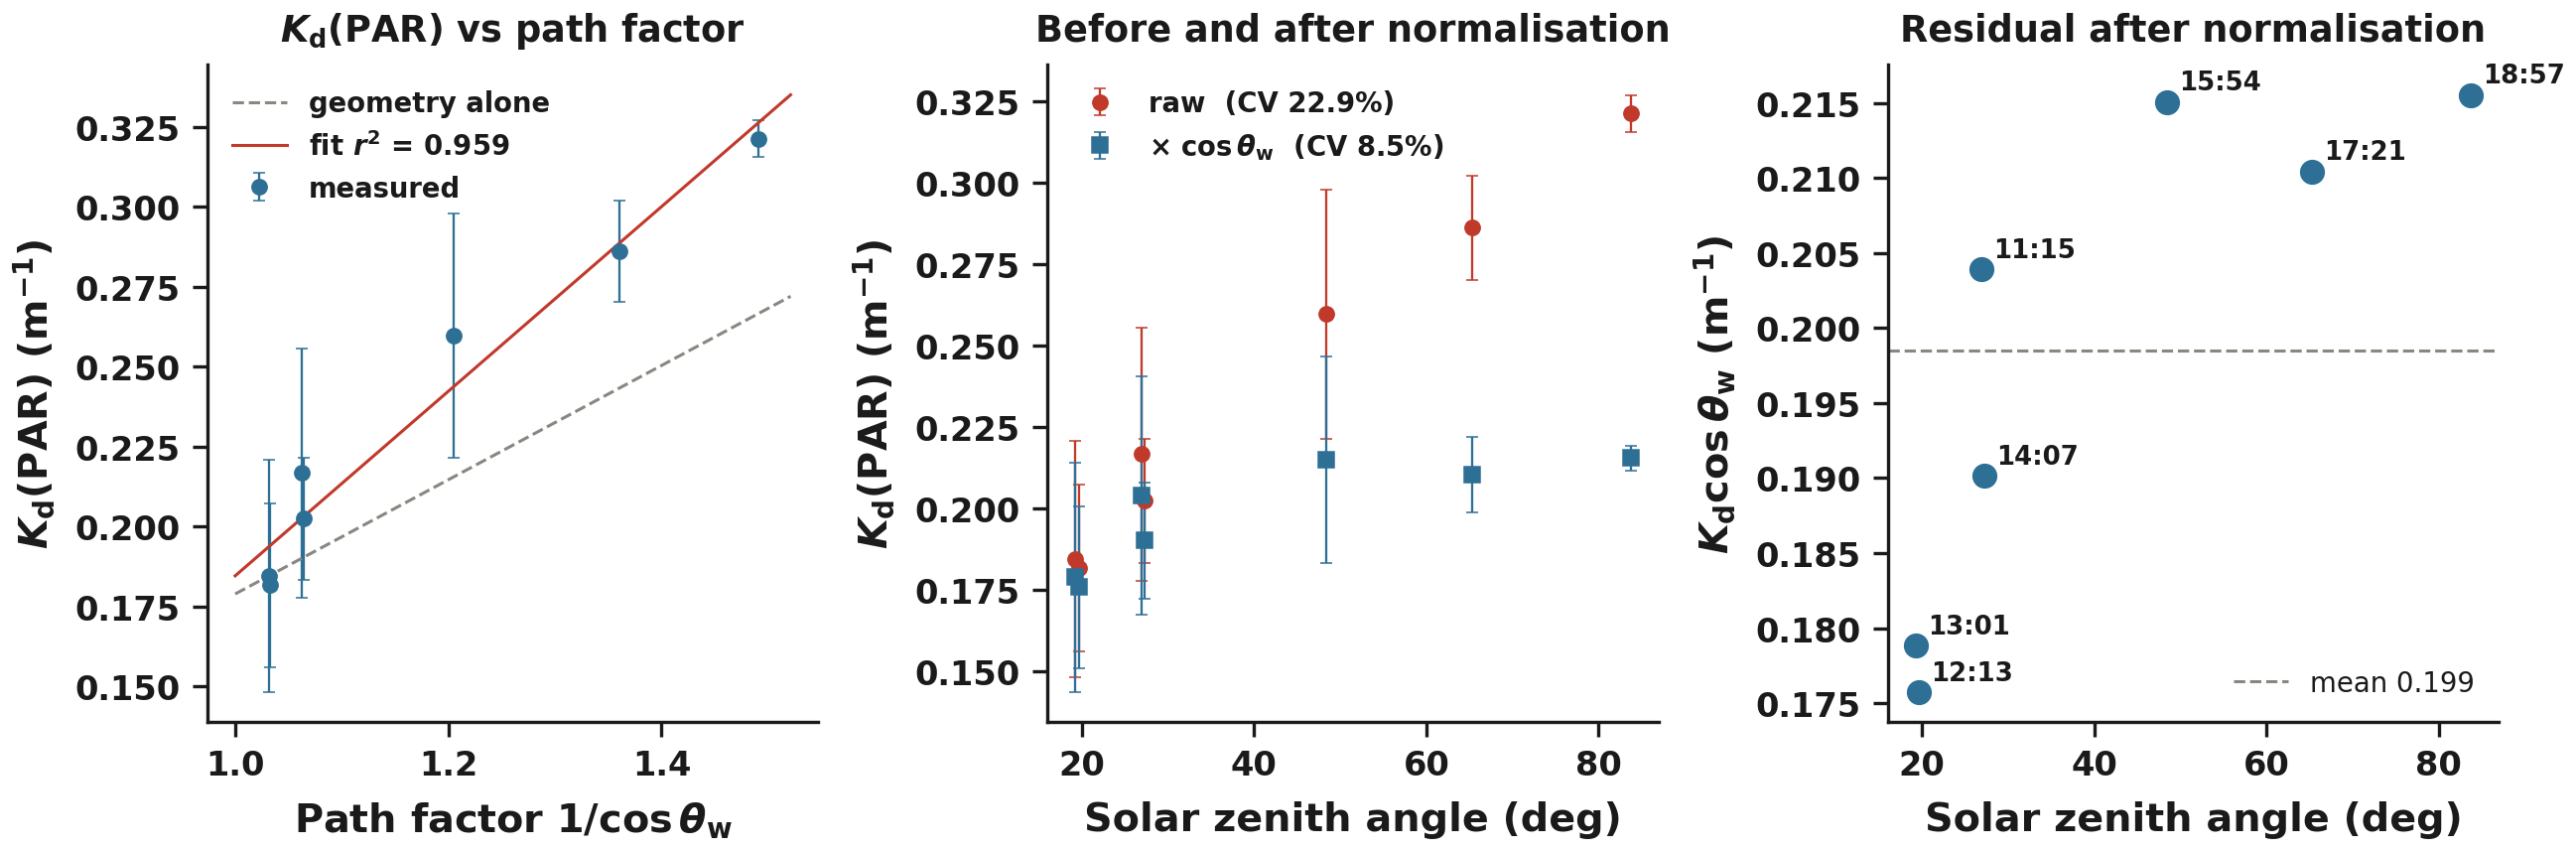

fit uses: all stations  (n=7)
path-factor span 0.459

  geometry alone predicts   44.5%
  observed change in Kd     77.0%
  residual after cos θw     22.6%
  CV  22.9%  ->  8.5%

  Kd = -0.1045 + 0.2890/cos θw   r²=0.959, p=0.0001
  extrapolated to overhead sun: Kd = 0.1845 /m

  residual vs SZA: slope +0.00055 /m per deg, p=0.023, r²=0.676
  -> residual still trends with sun angle - report the break point

NOTE: on a single solar limb, time and sun angle covary almost
perfectly, so the excess over the geometric prediction cannot be
uniquely partitioned between water-column change and instrument
response. Report the normalisation, not a fitted coefficient.


In [27]:
if "cloud_index" not in tbl:            # optional: join sky state from notebook 1
    ci_path = os.path.join(FIG_BASE, "E_sPAR_day")
    hits = [f for f in os.listdir(ci_path) if f.startswith("station_sky_")] \
           if os.path.isdir(ci_path) else []
    if hits:
        sky = pd.read_csv(os.path.join(ci_path, hits[0]))
        tbl = tbl.merge(sky[["station", "cloud_index"]], on="station", how="left")
        print("joined cloud index from", hits[0])

fig, corr = pio.fig_correction(tbl)
savefig(fig, "correction"); plt.show()

print(f"fit uses: {corr['which']}  (n={corr['n_used']})")
print(f"path-factor span {corr['pf_span']:.3f}\n")
print(f"  geometry alone predicts   {corr['predicted_pct']:.1f}%")
print(f"  observed change in Kd     {corr['observed_pct']:.1f}%")
print(f"  residual after cos θw     {corr['residual_pct']:.1f}%")
print(f"  CV  {corr['cv_raw']:.1f}%  ->  {corr['cv_norm']:.1f}%")
if "slope" in corr:
    print(f"\n  Kd = {corr['intercept']:.4f} + {corr['slope']:.4f}/cos θw"
          f"   r²={corr['r2']:.3f}, p={corr['p']:.4f}")
    print(f"  extrapolated to overhead sun: Kd = {corr['Kd_at_zenith']:.4f} /m")
    print(f"\n  residual vs SZA: slope {corr['resid_slope']:+.5f} /m per deg, "
          f"p={corr['resid_p']:.3f}, r²={corr['resid_r2']:.3f}")
    if corr["resid_p"] > 0.05:
        print("  -> residual is flat: the Kirk 1/cos θw model is sufficient, "
              "no additional correction warranted")
    else:
        print("  -> residual still trends with sun angle - report the break point")

print("\nNOTE: on a single solar limb, time and sun angle covary almost")
print("perfectly, so the excess over the geometric prediction cannot be")
print("uniquely partitioned between water-column change and instrument")
print("response. Report the normalisation, not a fitted coefficient.")

## Export

In [28]:
casts_df = pd.concat([s["kd_table"] for s in stations if len(s["kd_table"])],
                     ignore_index=True)
for name, df in [("kd_all_casts",casts_df),("station_summary",tbl),
                 ("depth_groups",grp),("focusing",fl)]:
    if len(df):
        df.to_csv(os.path.join(OUTDIR, f"{name}_{DAY}.csv"), index=False)
        print("saved", name)
print(f"\n{len(tbl)} stations | {len(casts_df)} casts | "
      f"SZA {tbl.sza.min():.1f}–{tbl.sza.max():.1f}° | "
      f"Kd {tbl.Kd.min():.3f}–{tbl.Kd.max():.3f} /m")

saved kd_all_casts
saved station_summary
saved depth_groups
saved focusing

7 stations | 67 casts | SZA 19.3–83.7° | Kd 0.182–0.321 /m


---
Kirk, J.T.O. (1984). *Limnol. Oceanogr.* 29(2), 350–356.
Gordon, H.R. (1989). *Limnol. Oceanogr.* 34(8), 1389–1409.
Reda, I. & Andreas, A. (2004). *Solar Energy* 76(5), 577–589.
Zaneveld, J.R.V., Boss, E. & Barnard, A. (2001). *Appl. Opt.* 40(9), 1442–1449.